# **Finetuning**

**Overview**

**What is fine-tuning?**
 * Fine-tuning means taking a model that has already been trained on a huge amount of general data (a **pretrained model**) and training it a little more on a smaller dataset for a specific task.
    - For example, teaching an LLM that already knows language to answer "y" or "n" for our classification task. Instead of learning from scratch, the model adjusts the knowledge it already has.

**Elements we should know**

*The building blocks*
* **Inputs:** The information given to the model, as numbers. For an LLM, the text is first split into tokens, and each token becomes a vector of numbers.

* **Node (neuron):** A small unit that multiplies each of its inputs by a weight, adds them up, and passes the result on.

* **Weights:** The numbers on the connections between nodes. They hold the model's knowledge and are what training changes.

* **Bias**: An extra number added to each node's weighted sum, which shifts the result up or down. Weights and biases together are the model's **parameters**.

* **Layers**: Groups of nodes. The input layer receives the data, **hidden layers** transform it step by step, and the output layer gives the prediction. "Deep" learning means many hidden layers.

* **Activation function**: A small non-linear step applied after each node's weighted sum (for example **ReLU**, which turns negative values into 0). Without it, stacked layers would collapse into a single one and the model couldn't learn complex patterns.
    * Rectified Linear Unit ReLU, it is usually for the hidden layers
    * The output layers get a different function depending on the task
      - Sigmoid is for Binary classification probability for each class, a probability between 0 and 1
      - Softmax multiclass LLM over the whole vocabulary a probability for the tokens

* **Output:** The model's prediction. For our LLM, a probability for every possible next token, such as P("y") and P("n").



*How the model learns*
* **Forward propagation:** Passing the input forward through the layers (dot products + activations) to produce a prediction.

* **Loss function**: Measures how wrong the prediction is compared with the correct answer. Training tries to make this number as small as possible. For our yes/no task, it's **cross-entropy**.

* **Backpropagation:** Working backwards from the loss to the input to figure out how much each weight contributed to the error.

* **Gradient:** The result of backpropagation: for each weight, the direction and size of the change that would reduce the loss.

* **Gradient descent (optimizer):** The rule that uses the gradients to update the weights: new weight = old weight − learning rate × gradient. 
        
       *  **Adam** is the most common variant.

* **Learning rate:** How big each update step is. Too small and training is slow; too large and the loss bounces around instead of going down.

* **Epoch and batch**: A **batch** is the group of examples processed together in one training step. An **epoch** is one full pass through the whole training dataset.

# **Padding in LLMs**



**Padding** means adding filler tokens to shorter sequences so that every sequence in a batch has the same length.
* LLMs process text as sequences of **tokens**.
* For speed, GPUs process many sequences at once in a **batch**, stored as a rectangular tensor (a grid of numbers)
   * Every row in that grid must be the same length, but real sentences vary in length. So shorter sentences are filled with a special **padding token** (often `[PAD]` or `<pad>`) until they match the longest one.
   




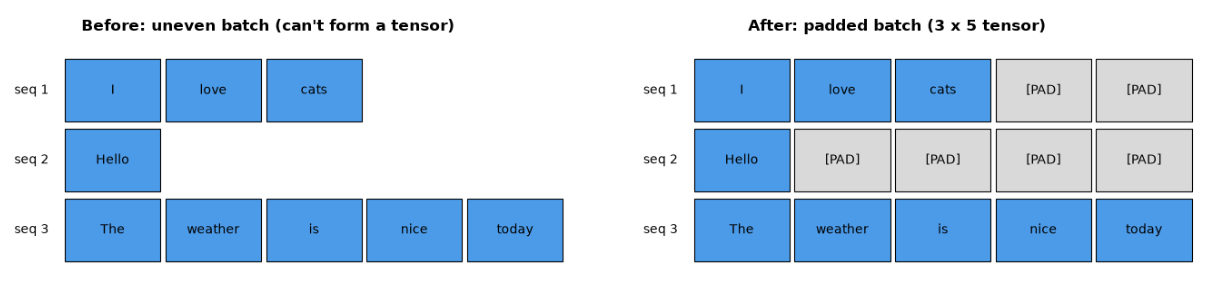

## **Tokenization**

After tokenization, each word becomes a number (token ID). Here we use a toy vocabulary and pad with ID `0`.

| Sentence | Token IDs |
|---|---|
| "I love cats" | `[101, 1045, 2293, 8870]` |
| "Hello" | `[101, 7592]` |
| "The weather is nice" | `[101, 1996, 4633, 2003, 3835]` |

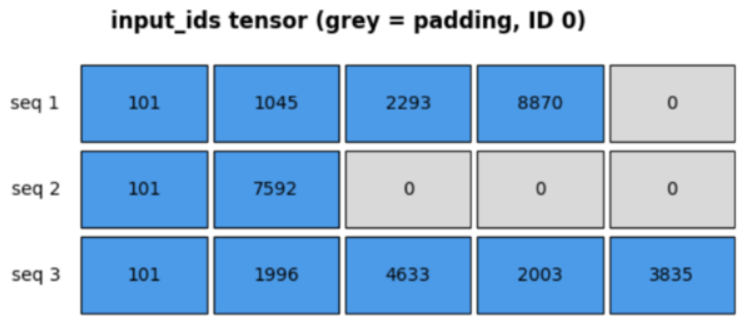

The longest sequence has 5 tokens, so the others are padded to length 5

## **Attention Mask**

* Padding tokens carry no meaning, but a Transformer's attention layers look at **every** token in a sequence. If nothing stops them, padding tokens change the model's output.
* The fix is an **attention mask**: a tensor with the same shape as `input_ids`, containing:
- `1` = real token, attend to it
- `0` = padding, ignore it

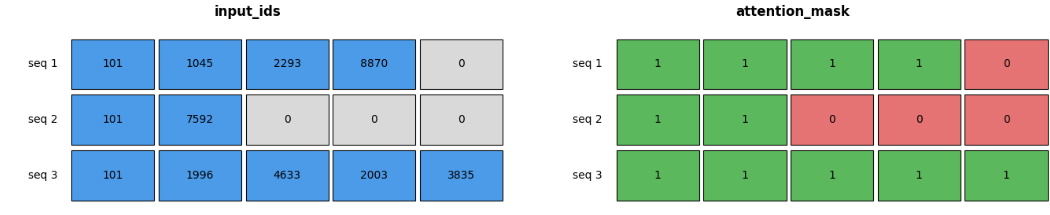

## **Padding Side**: Left vs Right

* **Left padding** (pads at the start) is preferred for **text generation** with decoder-only LLMs like GPT, LLaMA, or Mistral.
   * A decoder-only model predicts the next token from the **last position** in the row. With right padding, the last position of a short prompt is a `[PAD]` token, and the model was never trained to continue from padding
     * padding_side = "left"

* **Right padding** (pads at the end) is the standard choice for training and finetuning. Why training uses right padding?
  * padding_side = "right"
     * Training doesnt happen from the end, it is computing the whole system and expect real content from the start position.
  

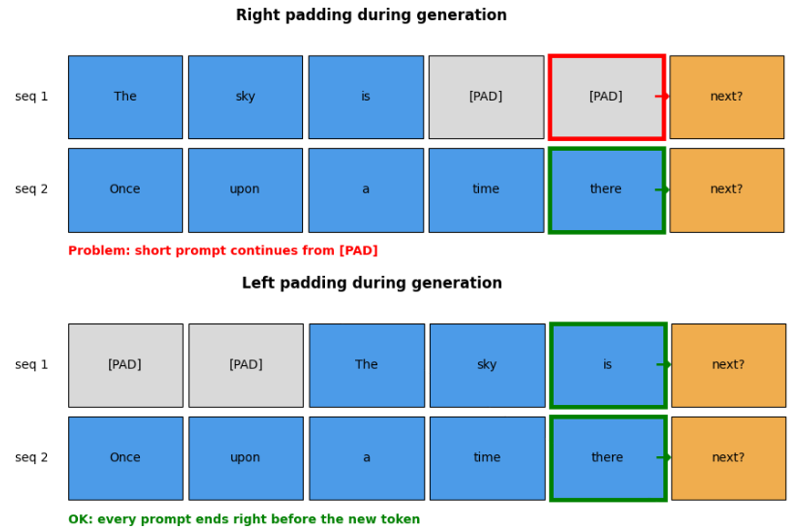

## **Padding and EOS**

* eos_token is a special token representing the end of a sentence.
* model.generate() needs to know whn to generate tokens, the model uses end of sequence tokens to indicate that a sequence of text has finished
  * We know that model predicts tokens, when the model see eos token, it signanls to the model that is should stop or that a sequence stop

In [1]:
%pip install -q "trl==1.13.0" "transformers==5.17.0" "peft==0.21.0" accelerate datasets "bitsandbytes>=0.46.1"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Padding and Eos in practice with HuggingFace

* In Hugging Face, the **tokenizer** does the padding and builds the attention mask, so we only need to choose the settings.

### Example

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cpu"

# model_id = "HuggingFaceTB/SmolLM2-135M-Instruct"    # very small model

# model_id = "meta-llama/Llama-3.2-1B-Instruct"

# model_id = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             dtype=torch.float16).to(device) #dtype = torch.float32
                                                                             # this is precision conversion

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 331.01it/s]


In [69]:
print("EOS token     :", tokenizer.eos_token)                  # <|im_end|>
print("EOS token ID  :", tokenizer.eos_token_id)               # 2
print("Model stops on:", model.generation_config.eos_token_id) # 2
print("PAD token   :", tokenizer.pad_token, tokenizer.pad_token_id)

EOS token     : <|im_end|>
EOS token ID  : 151645
Model stops on: [151645, 151643]
PAD token   : <|endoftext|> 151643


In [59]:
# Ask for a longer answer
messages = [{"role": "user",
             "content": "Write three sentences about why cats make good pets."}]

text = tokenizer.apply_chat_template(messages,
                                     tokenize=False, # Provide the text, no the token id, tokenize = True provide token id
                                     add_generation_prompt=True) #this add the assistant turn at the end of the text
                                                                 #<|im_start|>assistant example
inputs = tokenizer(text,
                   return_tensors="pt").to(device) #pt means to tell the tokenizer to return PyTorch tensors

max_new = 200
outputs = model.generate(**inputs,
                         max_new_tokens=max_new,
                         do_sample=False,        # how the model picks th next tokens, do_sample = false means to always pick the most likely token
                         repetition_penalty=1.2) # makes the model less likely to reuse tokens that have already appeared

new_ids = outputs[0, inputs["input_ids"].shape[-1]:]

The chattemplates adds alot to the input hidden tokens

In [60]:
inputs

{'input_ids': tensor([[128000, 128000, 128006,   9125, 128007,    271,  38766,   1303,  33025,
           2696,     25,   6790,    220,   2366,     18,    198,  15724,   2696,
             25,    220,   2371,   5020,    220,   2366,     21,    271, 128009,
         128006,    882, 128007,    271,   8144,   2380,  23719,    922,   3249,
          19987,   1304,   1695,  26159,     13, 128009, 128006,  78191, 128007,
            271]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [61]:
# See the full text the model receives
print(text)

# See each token with its ID
for i, token_id in enumerate(inputs["input_ids"][0].tolist()):
    print(f"{i:>2}  {token_id:>6}  {tokenizer.decode([token_id])!r}") #!r invisible characters make those visible

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 04 Oct 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Write three sentences about why cats make good pets.<|eot_id|><|start_header_id|>assistant<|end_header_id|>


 0  128000  '<|begin_of_text|>'
 1  128000  '<|begin_of_text|>'
 2  128006  '<|start_header_id|>'
 3    9125  'system'
 4  128007  '<|end_header_id|>'
 5     271  '\n\n'
 6   38766  'Cut'
 7    1303  'ting'
 8   33025  ' Knowledge'
 9    2696  ' Date'
10      25  ':'
11    6790  ' December'
12     220  ' '
13    2366  '202'
14      18  '3'
15     198  '\n'
16   15724  'Today'
17    2696  ' Date'
18      25  ':'
19     220  ' '
20    2371  '04'
21    5020  ' Oct'
22     220  ' '
23    2366  '202'
24      21  '6'
25     271  '\n\n'
26  128009  '<|eot_id|>'
27  128006  '<|start_header_id|>'
28     882  'user'
29  128007  '<|end_header_id|>'
30     271  '\n\n'
31    8144  'Write'
32    2380  ' three'
33   237

In [62]:
answer = tokenizer.decode(new_ids, skip_special_tokens=False) #special tokens are skipped im_end, begin_of_text
print("Full answer:", repr(answer))

# Show the last 8 tokens
print("\nLast tokens:")
for tid in new_ids[-8:].tolist():
    token = tokenizer.decode([tid])
    if tid == tokenizer.eos_token_id:
        print(tid, repr(token), "<-- EOS")  # repr is doing the same thing as !r showing the text exactly as these are
    else:
        print(tid, repr(token))

stopped_by_eos = new_ids[-1].item() == tokenizer.eos_token_id
print(f"\nGenerated {len(new_ids)} of max {max_new} tokens")
print("Stopped because of:", "EOS" if stopped_by_eos else "max_new_tokens limit")

Full answer: 'Cats are often considered one of the best pets due to their low-maintenance lifestyle, as they require minimal attention and exercise compared to dogs or other animals that need regular walks and training sessions. Their independence also makes them a great fit for busy owners who value flexibility in their daily routine. Additionally, many cat breeds have unique personalities that can provide companionship and affection without requiring constant interaction from their human family members.<|eot_id|>'

Last tokens:
16628 ' interaction'
505 ' from'
872 ' their'
3823 ' human'
3070 ' family'
3697 ' members'
13 '.'
128009 '<|eot_id|>' <-- EOS

Generated 84 of max 200 tokens
Stopped because of: EOS


In [63]:
print("Tokens in the answer:", len(new_ids))

Tokens in the answer: 84


Example 1

Show them the error

Qwen silent error

In [ ]:

from transformers import AutoTokenizer

#Models
# model_id = "HuggingFaceTB/SmolLM2-135M-Instruct"    # very small model
# model_id = "meta-llama/Llama-3.2-1B-Instruct"
model_id = "Qwen/Qwen2.5-0.5B-Instruct"


# download the tokenizer for the model

# tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")

tokenizer = AutoTokenizer.from_pretrained(model_id, 
                                          padding_side="left") #padding_side="right"
 

tokenizer.pad_token = tokenizer.eos_token     # llama has no pad token       # herre

# tokenizer.pad_token = tokenizer.pad_token  





model = AutoModelForCausalLM.from_pretrained(model_id,
                                             dtype=torch.float16).to(device)

model.config.pad_token_id = tokenizer.eos_token_id

# model.config.pad_token_id = tokenizer.pad_token_id

texts = ["I love cats", "Hello", "The weather is nice today"]

enc = tokenizer(
    texts,
    padding=True,          # pad to the longest sequence in the batch
    truncation=True,       # cut sequences longer than max_length
    max_length=512,
    return_tensors="pt",   # return PyTorch tensors
)

print(enc["input_ids"])
print(enc["attention_mask"])


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 325.42it/s]

tensor([[151645, 151645,     40,   2948,  19423],
        [151645, 151645, 151645, 151645,   9707],
        [   785,   9104,    374,   6419,   3351]])
tensor([[0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1]])


In [77]:
print(model.config.pad_token_id)
print(model.config.eos_token_id)

151645
151645


In [ ]:

from transformers import AutoModelForCausalLM, AutoTokenizer

# model_id = "meta-llama/Llama-3.2-1B-Instruct"
# model_id = "HuggingFaceTB/SmolLM2-135M-Instruct"

model_id = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id,
                                          padding_side="left")  # left for inference

# tokenizer.padding_side = "left" 

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             dtype=torch.float16).to(device)


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 309.83it/s]


In [84]:
print(model.config)

Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "float16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 896,
  "initializer_range": 0.02,
  "intermediate_size": 4864,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention"
  ],
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 14,
  "num_hidden_layers": 24,
  "num_key_value_heads": 2,
  "pad_t

In [85]:
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [ ]:
# this is for the tokenizer
tokenizer.pad_token = tokenizer.eos_token # I want pad equal eos  HEREEEEEEEEEE

# this is for the model
model.config.pad_token_id = tokenizer.eos_token_id    # tell the model which ID is padding HEREEEEE

prompts = ["The sky is", "Once upon a time there was"]

inputs = tokenizer(prompts,
                   padding=True,
                   return_tensors="pt")

# to generate we are telling the model which PAD fill sequence to use to finish a batch
outputs = model.generate(
    **inputs,                          # passes input_ids AND attention_mask
    max_new_tokens=20,
    pad_token_id = tokenizer.eos_token_id, # HEREEEEEEEEEEEEEEEE
)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

['The sky is blue because of water. What color is the sky if it is not made up of water? To', 'Once upon a time there was a man who lived in a village. He had two sons, and they were both very smart.']


## Why is this relevant?


**PADDING**
* When we do batching, the training step takes x example from different lenths
  1. These must be padded into rectangles. Behind the scene the data collector pads every batch into its on longest sequence
     * Thanks this DataCollatorForLanguageModeling
  2. processing_class = hf_tokenizer, this tell which token to pad, at this point the model MUST have a padding token, now if it doesnt the TRL finds the model EOS tokn and thoses the PAD=EOS

**EOS**
When model checks accuracy, or when it learns from it the completion
 * When learning is happening completion_only_loss = True
 * Completition of learning should stop at the classification yes or no
 * But what the model sees is "y" + EOS
   * Whn the modl is learning it is larning the labels and to stop right after it.

### Resources

* [Padding Info](https://huggingface.co/docs/transformers/main/en/pad_truncation)
* [Handling multiple sequences](https://huggingface.co/learn/llm-course/chapter2/5)
* [Token, Padding and More!](https://huggingface.co/docs/transformers/llm_tutorial)
* [Begining of Sequence bos, and end of sequence eos](https://docs.pytorch.org/docs/2.6/generated/torch.nn.CrossEntropyLoss.html)

* [Padding and EOS Medium](https://medium.com/@khalandar.mokula/understanding-eos-token-and-pad-token-in-model-generate-config-huggingface-transformers-fef6845ed92a)
* [End of sequence](https://huggingface.co/docs/transformers/en/main_classes/tokenizer)

# **Quantization**



**Model Computation**

* Model computation are done using floating-point numbers
* The precision of these number impact how accurately the model performs in different task such as training and inferences.
* Floating Point Representation: Mantissa, Exponent, and Sign. A floating-point number is made up of three parts:     
    * **The mantissa**
      * Mantissa: fraction significant digits more bits allocated here more accurate the number, precision
    * **The exponent**
      * Exponent the scale or range of the number, how far left or right it should be (how big or small)
    * **The sign bit**
      * The number sign, a whole bit just dedicated to know if the number is positive or negative
         * which direction to learn (increase or decrease the weight)

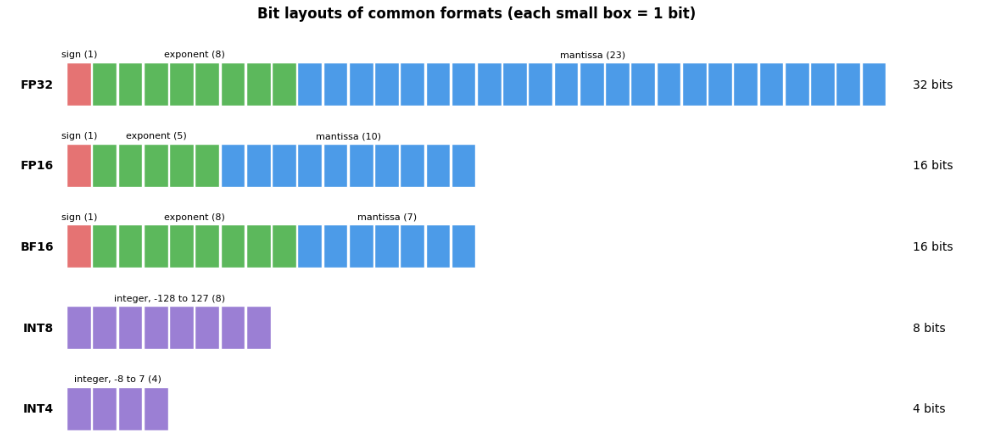

**Torch dtype** is the numeric precision of the models weights.
  * **FP32 (32-bit floating point):** This is the standard data type for many machine learning applications. It provides high precision, with 23 bits for the mantissa and 8 as exponent. However, the high precision comes at the cost of large memory usage and slower computations.
    
  * **FP16 (16-bit Floating Point)**: This is a compromise between speed and accuracy. It reduces memory usage and speeds up computations but sacrifices some precision.

  * **Bfloat16 (Brain Floating Point)**: This is a more recent development designed for deep learning tasks. It has 8 exponent bits but 7 mantissa bits. It keeps the exponent size from FP32 but reduces the mantissa size. Bfloat16 maintains the dynamic range of FP32, making it  useful for training large models, though it still comes with the trade-off of needing specialized hardware and being more expensive than lower-precision types like FP16.
    * ERROR: cannot use bf15 with T4 or even L4 GPU, to use bf16 the newer gpu are needed like A100

Why?
* LLM are big and hard to run, to do inferences on a 176B model the resources needed are about 8x 80GB A100 GPU ($15k each).
* We need a way to rduce these requirmnts while preserving models' performance.



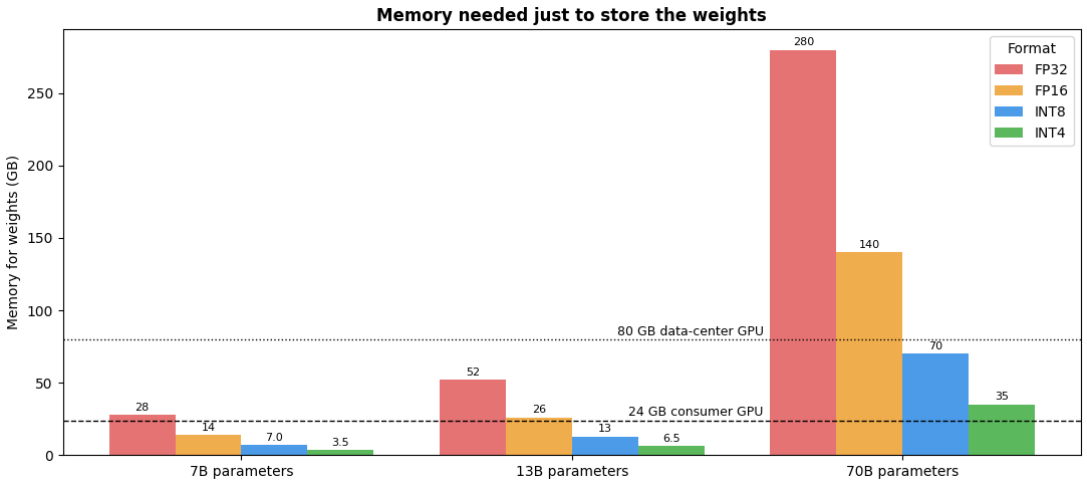

Remember
* Bits binary two values 0 or 1
* Bytes are 8 Bits
* 1 KB (1,000 bytes)
* 1 MG (megabyte), means 1 million bytes
* 1GB is 1b bytes (1,000,000,000)

So a 7B models 
  - number of weights x 2 bytes per weight =  7b x 2 bytes = 14GB, which is 14,000,000,000 bytes
       * IF BF16, each number uses 16 bits, each weight is one number
       * now from bits to bytes 16bits/8 = 2 bytes


What it is?
* **Quantization** is a technique used to reduce the memory and computational requirements of a model by representing its weights and/or activations using lower-precision numerical formats, such as 8-bit integers (int8) or 4-bit values, instead of higher-precision formats such as 32-bit floating point (float32).

* **Quantization** is all about making your model lighter and faster without hurting its accuracy.
* It helps lower memory usage, model size and computational cost

   * **Weight Quantization**: compresses the trained model's parameters (the weights) to save memory and storage.
       *  Used for **inference** (e.g. loading a model in 4-bit or 8-bit so it fits on a smaller GPU) and, with **QLoRA**, during **training**. 
         * So, frozen weights are stored in 4bit NF4
       * Remember: Weights are the model's stored parameters. Quantizing them saves memory and storage. 

   * **Activation Quantization**: compresses the output generated during inference.
       * convert the activations from FP16 to 4-bit, we need FP16 because they need to be in higher precision for the matrix multiplication (×). 
       * But QLoRA does not quantize activation, they stay in BF16 throughout

**Quantization** converts high-precision values into a small set of low-precision values (for NF4, a 4-bit code per weight plus a scale per block). 

**Dequantization** converts them back to higher precision so the computation (the matrix multiplication) can be done accurately.

* This is the process of first quantizing the weights to, for example, INT4 and then dequantizing back to FP32

### References

* [A Visual Guid to Quantization (This is a really nice reading)](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-quantization)
* [Quantization Method](https://huggingface.co/docs/transformers/v5.17.0/en/quantization/overview)
* [A Gentle Introduction to 8bit Matrix Multiplication](https://huggingface.co/blog/hf-bitsandbytes-integration)
* [What is Quantization huggingface](https://huggingface.co/docs/optimum/en/concept_guides/quantization)
* [What is Quantization geeksforgeks](https://www.geeksforgeeks.org/deep-learning/quantization-in-deep-learning/)
* [The benefits of quantization](https://developer.nvidia.com/blog/model-quantization-concepts-methods-and-why-it-matters/)
* [Quantization and Training of Neural Network for Efficient Intger-Arithmtic-Only Inference](https://arxiv.org/pdf/1712.05877)
* [Quantization Types](https://huggingface.co/docs/hub/en/gguf#quantization-types)
* [More and more](https://blog.eleuther.ai/transformer-math/)

**Paper**
[QLoRA fficient finetuning of Quantized LLMs](https://arxiv.org/pdf/2305.14314)

## Quantization in practice with Hugging Face

Loading a model in 4-bit with bitsandbytes takes one config object. This needs an NVIDIA GPU (a free Colab T4 works) and:


Notice `bnb_4bit_compute_dtype`: the weights are **stored** in 4-bit, but they are dequantized to BF16 on the fly for the calculations. That's why quantization mostly saves memory rather than changing the model's math.



In [ ]:
#%pip install transformers accelerate bitsandbytes
%pip install -q "trl==1.13.0" "transformers==5.17.0" "peft==0.21.0" accelerate datasets "bitsandbytes>=0.46.1"

In [90]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


# model_id  ="HuggingFaceTB/SmolLM2-135M-Instruct"
model_id = "meta-llama/Llama-3.2-1B-Instruct"

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             device_map="auto",
                                             dtype=torch.float16)
tokenizer = AutoTokenizer.from_pretrained(model_id)

print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

Loading weights: 100%|██████████| 146/146 [00:02<00:00, 69.22it/s]


Memory footprint: 2.47 GB


In [89]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # NormalFloat 4
    bnb_4bit_use_double_quant=True,        # also quantize the block scales
    bnb_4bit_compute_dtype=torch.bfloat16, # dequantize to BF16 for the calculation
)

model = AutoModelForCausalLM.from_pretrained(model_id, 
                                             quantization_config=bnb_config, 
                                             device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")


Loading weights: 100%|██████████| 146/146 [00:08<00:00, 17.23it/s]


Memory footprint: 1.01 GB


# **Parameter-Efficient Fine-Tunning (PEFT): LoRA and QLoRA**

**Recap**
* An LLM is first pretrained on a huge amount of general text, this process teaches the model language and general knowledge, the result is set of weights, billions of number stored in big matrices (can be representd as W).

So What is **Finetuning**?
* Fine-tuning means taking that pretrained model and continuing to train it on a smaller, specific task.
* Finetuning changes the weight. If originals weights are W then the finetune weights are W+deltaW


## **Full finetuning too expensive**

* In **full fine-tuning**, every weight in the model is updated. With the usual Adam optimizer and mixed precision, each trainable parameter needs roughly
* Every weight is changed directly, so after training W has ben overwritten with new values

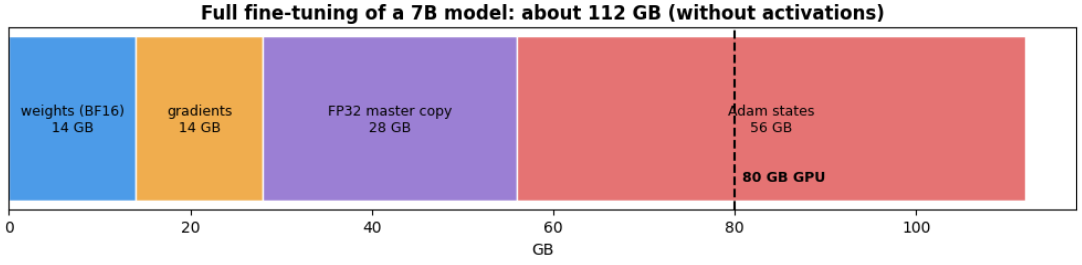

* So a 7B model needs about **112 GB** just for these, before counting activations. That's more than a single 80 GB GPU.
  * Weights (BF16), stored in 16bits which is about 2bytes, 7Bx2bytes = 15GB, just running the model
  * Gradients, 2bytes, 14GB. Gradient tells the model which directions should the weight move
    * loss smaller? how big?
    * sign tells the direction(increase of decreases)
    * The size is about how much the weight afects the mistakes

  * FP32 master copy, 4bytes. The optimizer does is to keep a copy of the model, applies the tiny updates to that copy then it rounds it to th bf16 for a 7b this is 7B x4 bytes = 28GB

  * Adam optimizer, the optimizer is the rules that decides how to turn gradients, adams needs around 8bytes per weight, 56 GB.

  

Resources

* [funetuning](https://huggingface.co/docs/transformers/training)
* [Devlin et al. (2018). BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805)

## What is LoRA?

* LoRA (Low-Rank Adaptation) is a parameter-efficient fine-tuning method for large neural networks, introduced by Hu et al. (2021).
  * It freezes the pretrained weights of a model and represents the weight update learned during fine-tuning as the product of two small, trainable low-rank matrices.
* W is frozen and never changes. Only the new A and B matrices are trained and added on top.
* LoRA only needs the weights...FROZEN...
* Th other three pieces, gradients, master copy, Adam state are not needed since LoRA does not change the orignal weights directly

* LoRA only needs the A and B skinny matrices which are about .6GB
* If using QLoRA, it shirks the frozen weights lets says from 14GB to about 3.6 GB by storing them in 4bit.

## Key Ideas of LoRA

Fine-tuning changes a weight matrix $W$ into a new one:

$$W_{\text{new}} = W + \Delta W$$

In full fine-tuning, $\Delta W$ has the same size as $W$. For a $4096 \times 4096$ layer, that's about 16.8 million numbers to learn.

LoRA **freezes** $W$ and writes the change as the product of two thin matrices:

$$\Delta W = B \, A \qquad B: d \times r, \quad A: r \times k$$

where the **rank** $r$ is small (for example 8 or 16). For the same $4096 \times 4096$ layer with $r = 16$:

$$4096 \times 16 + 16 \times 4096 = 131{,}072 \text{ numbers} \quad (\text{about } 0.8\% \text{ of the layer})$$

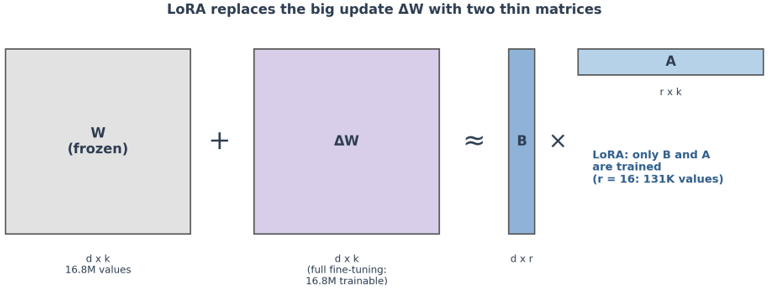

Remember,
*  In our QLoRA setup: the **frozen base weights** are stored in **4-bit NF4** and dequantized to BF16 on the fly for each calculation. The **trainable LoRA weights (A and B) stay in BF16**.

The shape of W
* W is d x k (d is output and K in input)
* A is r x k (takes the layer input)
* B is d x r (takes the ouput size layer)
  * A and B ar created by LoRA
  * training fills in their values and then are saved as adapters
  * We load th orignal base modl and attach those savd A and B matrices to it

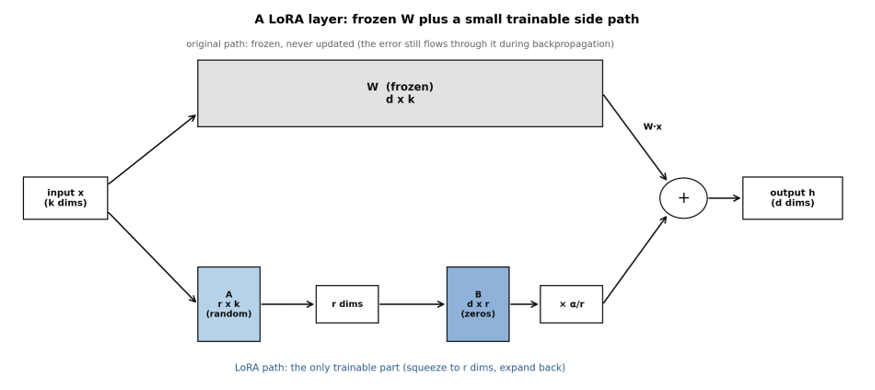

* We can only add two lists of numbers if they have the same length. W·x has d numbers, so the LoRA path must also end with d numbers
  - That is B's job its shape d x r to match the same size of  W*x, it turns r numbers back into d number
  - B weights start at 0 so LoRA add nothings until training begins

**Just a quick intro**
* r is a vector of r number, we can change the value
  * if r = 16, if input features are many it squeezes into 16 features

* scale =alpha/r
  * lora_alpha/r
    * it controls how strong the LoRA updates affect the output
       * large alpha/r mean LoRA has a bigger effect, model changes faster during training
       * Smaller alpha/r smaller effct, changes are more gradual

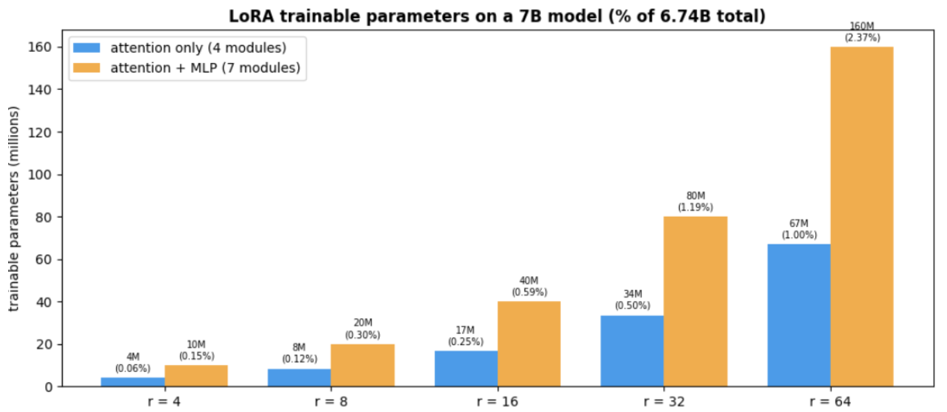

## QLoRA

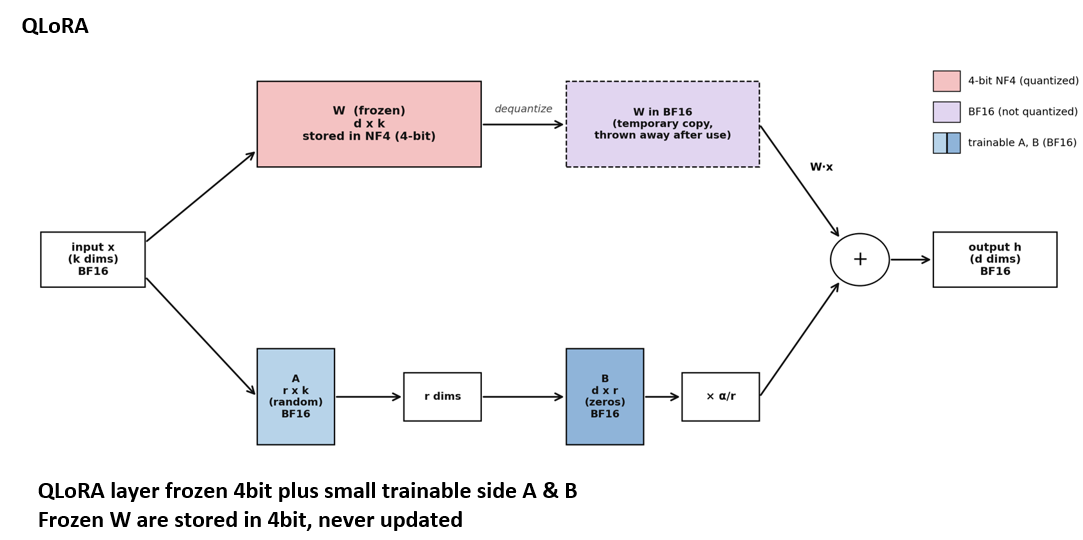

Outliers
* **Double quantization** (used in QLoRA) reduces this by quantizing the scales themselves. Another approach, **LLM.int8()**, keeps outliers in 16-bit and quantizes everything else to 8-bit.

### References

Papers
* [LoRA: Low-Rank Adaptation of Large Language Models (Hu et al., 2021)](https://arxiv.org/abs/2106.09685)
* [QLoRA: Efficient Finetuning of Quantized LLMs (Dettmers et al., 2023)](https://arxiv.org/abs/2305.14314)
* [QLoRA (Quantized Low-Rank Adapter) geksforgeeks](https://www.geeksforgeeks.org/deep-learning/qlora-quantized-low-rank-adapter/)

# Code Here START

In [ ]:
%pip3 install -r requirements.txt

In [ ]:
%pip install -q "trl==1.13.0" "transformers==5.17.0" "peft==0.21.0" accelerate datasets "bitsandbytes>=0.46.1"

In [ ]:
%pip install -U transformers accelerate bitsandbytes

In [ ]:
'''
try:
    import os
    from google.colab import drive
    from google.colab import userdata
    drive.mount('/content/drive/')
    os.chdir("./drive/MyDrive/llm-text-classification/")

    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
    print("Environment = Colab")
except ImportError:
    from dotenv import load_dotenv

    !git pull
    load_dotenv()
    print("Environment = Local")
'''
try:
    import os
    from google.colab import drive
    from google.colab import userdata

    drive.mount('/content/drive/')

    os.chdir('/content/drive/MyDrive/llm-text-classification/')

    os.environ["HF_TOKEN"] = userdata.get("B-Llama-3.1-8B-Access")

    print("Environment = Colab")

except ImportError:
    from dotenv import load_dotenv

    !git pull
    load_dotenv()

    print("Environment = Local")


Already up to date.
Environment = Local


In [33]:
import os
from datetime import datetime
from dotenv import load_dotenv
from pathlib import Path
from huggingface_hub import login
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

In [34]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nUsing device: {DEVICE}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))


Using device: cpu


In [35]:
WORKING_DIR = Path.cwd()
DATA_DIR =  WORKING_DIR / "data"
DATA_MANAGEMENT_DIR = WORKING_DIR / "data_management"
RESULTS_DIR = WORKING_DIR / "results"

In [37]:
DATA_SOURCE = "train" # train, dev, test

path_to_data = DATA_DIR / f"{DATA_SOURCE}.xlsx"
df = pd.read_excel(path_to_data)

In [43]:
print("WORKING_DIR:", WORKING_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("DEVICE:", DEVICE)

WORKING_DIR: c:\Users\Claudia\Documents\GitHub\llm-text-classification
DATA_DIR: c:\Users\Claudia\Documents\GitHub\llm-text-classification\data
RESULTS_DIR: c:\Users\Claudia\Documents\GitHub\llm-text-classification\results
DEVICE: cpu


In [102]:
print(f"\nUsing device: {DEVICE}")
if DEVICE == "cuda":
    if torch.cuda.is_bf16_supported():
        PRECISION = torch.bfloat16
    else:
        PRECISION = torch.float16
    print(torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU found: 4-bit QLoRA training requires CUDA.")


Using device: cpu


RuntimeError: No GPU found: 4-bit QLoRA training requires CUDA.

In [ ]:
# float32 = full precision for CPU
# can use bfloat16 if cuda is available (float for cpu, bfloat for gpu)


In [ ]:
MODEL = "meta-llama/Llama-3.2-1B-Instruct"
PROMPT_ID = "baseline_c0t1d1g0"
RANDOM_STATE = 42
TASK_TYPE = "CAUSAL_LM"
LEARN_RATE = 2e-4  # 0.0002
TRAIN_SAMPLE_NAME = "train_balanced"
DROP_LONG_CASES = False
DESCRIPTION = "basePrompt_baseConfig"

In [91]:
# import data
DATA_SOURCE = "train" # train, dev, test

path_to_data = DATA_DIR / f"{DATA_SOURCE}.xlsx"
train = pd.read_excel(path_to_data)
train["word_counts"] = train["text"].str.split(" ").str.len()
train

,index,filename,speaker,timestamp,text,prompt_coder1,prompt_coder2,prompt_coder3,code_human,word_counts
0,78,15309888_1.xlsx,Student 3,21:16,102030 4050 6070 8090 110 100 1100 1200---,0,0,0,0,8.0
1,79,15309888_1.xlsx,Teacher,21:27,"Okay, so can you write your what your answer i...",1,1,1,1,44.0
2,80,15309888_1.xlsx,Student 6,21:45,113,0,0,0,0,1.0
3,81,15309888_1.xlsx,Teacher,21:46,How did you get because I don't see I don't se...,1,1,1,1,20.0
4,82,15309888_1.xlsx,Student 6,21:50,"I just, I just counted by tens, like I did yes...",0,0,0,0,11.0
...,...,...,...,...,...,...,...,...,...,...
3724,132,96286269_2.xlsx,Teacher,41:57,"Yeah. It well, it happens when there's 50, som...",1,1,1,1,78.0
3725,133,96286269_2.xlsx,Student,42:32,I put 50 tally marks and took 23 away.,0,0,0,0,9.0
3726,134,96286269_2.xlsx,Teacher,42:39,Okay,0,0,0,0,1.0
3727,135,96286269_2.xlsx,Student,42:40,And I got the answer 27,0,0,0,0,6.0


In [53]:
max_utterance_len = train["word_counts"].max()
max_utterance_len


np.float64(2493.0)

In [92]:
DATA_SOURCE = "dev" # train, dev, test

path_to_data = DATA_DIR / f"{DATA_SOURCE}.xlsx"
dev = pd.read_excel(path_to_data)
dev

,index,filename,speaker,timestamp,text,prompt_coder1,prompt_coder2,prompt_coder3,code_human
0,0,10861631_1.xlsx,Teacher,00:04,I'm going to place up and I need you to tell m...,1,1,1,1
1,1,10861631_1.xlsx,Student 1,02:19,Counted two plus two plus two equals ten,0,0,0,0
2,2,10861631_1.xlsx,Teacher,02:28,But what do you think they chose this way to s...,1,1,1,1
3,3,10861631_1.xlsx,Student 2,02:44,there's four boxes and then it's a different w...,0,0,0,0
4,4,10861631_1.xlsx,Teacher,02:52,"Oh, they made it a different way",0,0,0,0
...,...,...,...,...,...,...,...,...,...
3534,134,94759808_2.xlsx,Student,27:59,you can decompose by ...,0,0,0,0
3535,135,94759808_2.xlsx,Teacher,27:59,"Okay, I need you paying attention. So talking ...",1,1,1,1
3536,136,94759808_2.xlsx,Student,28:10,By taking apart and putting 50 plus two?,1,1,1,1
3537,137,94759808_2.xlsx,Teacher,28:20,"Okay, could you 50 plus two, why can't I just ...",1,1,1,1


In [ ]:
dev

In [93]:
not_prompt_train = train[train["code_human"] == 0]
prompt_train = train[train["code_human"] == 1]
minority_rows = min(len(not_prompt_train), len(prompt_train))

In [94]:
train_balanced = pd.concat([
    not_prompt_train.sample(n = minority_rows, random_state = RANDOM_STATE),
    prompt_train.sample(n = minority_rows, random_state = RANDOM_STATE),
    ]).sample(frac = 1, random_state = RANDOM_STATE).reset_index(drop = True)

In [95]:
print("\nSAMPLE SIZE\n")
print(f"n train: {len(train):,}\n{train['code_human'].value_counts()}\n")
print(f"n train balanced: {len(train_balanced):,}\n{train_balanced['code_human'].value_counts()}\n")
print(f"n dev: {len(dev):,}\n{dev['code_human'].value_counts()}\n")


SAMPLE SIZE

n train: 3,729
code_human
0    2002
1    1727
Name: count, dtype: int64

n train balanced: 3,454
code_human
0    1727
1    1727
Name: count, dtype: int64

n dev: 3,539
code_human
0    1901
1    1638
Name: count, dtype: int64



In [ ]:
WORKING_DIR

In [96]:
MODEL = "meta-llama/Llama-3.2-1B-Instruct"
PROMPT_ID = "baseline_c0t1d1g0"
RANDOM_STATE = 42
TASK_TYPE = "CAUSAL_LM"
LEARN_RATE = 2e-4
TRAIN_SAMPLE_NAME = "train_balanced"
DROP_LONG_CASES = False

In [97]:
# ---- get prompt codebook Best----
path_to_prompts = WORKING_DIR / "data_management" / "empirical_prompts_50.csv"
prompts = pd.read_csv(path_to_prompts).fillna("")
prompt_dictionary = prompts.set_index("prompt_id").to_dict(orient = "index")

def prompt_case(case, p):
    parts = [
        p["context"],
        p["task"],
        p["definition"],
    ]

    # only include the guidance header if any guidance was drawn
    if len(p["guidance"]) > 0:
        parts.append(p["format_guidance"])
        parts.append(p["guidance"].strip())

    parts.append(p["format_case"])
    parts.append(f"\n\"\"\"{case}\"\"\"\n")                 # <- the case goes here
    parts.append(p["format_local"])    # e.g. output format instructions

    return "\n\n".join(part for part in parts if part)

# choose which prompt to use
# prompt_id = "baseline_c0t1d1g0"

# choose which prompt to use
prompt_id = PROMPT_ID

In [98]:
# choose which prompt to use

prompt_template = prompt_case("CASE", prompt_dictionary[prompt_id])
print(f"\n\nPROMPT TEMPLATE: {prompt_id}\n{prompt_template}\n\n")

prompt_len = len(prompt_template.split(" "))



PROMPT TEMPLATE: baseline_c0t1d1g0
Classify the following utterance as yes or no based on whether it is a dialogic prompt.

A dialogic prompt is defined as an utterance that implies, encourages, requests, or expects a new speaker (or multiple new speakers) to make a verbal contribution.

Here is the utterance:


"""CASE"""


Output format:
- First, give a brief explanation (1 short sentence, under 20 words) justifying your answer.
- Then give your final answer as a yes or no surrounded by three backticks. For example, ```yes``` or ```no```




Baseline prompt 

In [ ]:
'''
# ---- get prompt codebook ----
# this is the baseline prompt
path_to_prompts = WORKING_DIR / "data_management" / "llm_codebook.xlsx"
prompts = pd.read_excel(path_to_prompts)
prompt_dictionary = prompts.set_index("id")["prompt"].to_dict()

def prompt_case(case, p):
    parts = [
        p["task_1"],
        p["definition_1"],
        p["format_case"],
        ]

    parts.append(f"\n\"\"\"{case}\"\"\"\n")
    parts.append(p["format_local"])

    return "\n\n".join(part for part in parts if part)

prompt_template = prompt_case("CASE", prompt_dictionary)
print(f"\n\nPROMPT TEMPLATE\n{prompt_template}\n\n")

prompt_len = len(prompt_template.split(" "))
'''

In [99]:
# ---- set up model ----
login(token = os.getenv("HF_TOKEN"))

# finetuning
# meta-llama/Llama-3.2-1B-Instruct
# meta-llama/Llama-3.2-3B-Instruct
# ibm-granite/granite-4.2-3b
# Qwen/Qwen2.5-7B-Instruct
# ibm-granite/granite-4.2-8b

In [ ]:
PRECISION = torch.bfloat16

In [104]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = "nf4",
    bnb_4bit_compute_dtype = PRECISION,
    bnb_4bit_use_double_quant = True,
    )

In [ ]:
quantization_8bitconfig = BitsAndBytesConfig(
    load_in_8bit=True)

In [108]:

model = AutoModelForCausalLM.from_pretrained(MODEL,
                                             quantization_config = bnb_config, #quantization_8bitconfig, #bnb_config
                                             dtype = PRECISION, 
                                             #dtype = torch.float16,
                                             token = os.getenv("HF_TOKEN"),
                                             device_map = "auto") # initate pipeline

Loading weights: 100%|██████████| 146/146 [00:10<00:00, 13.51it/s]


In [106]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm

In [107]:
print(model.config)

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 8192,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 16,
  "num_key_value_heads": 8,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "quantization_config": {
    "_load_in_4bit": true,
    "_load_in_8bit": false,
    "bnb_4bit_compute_dtype": "bfloat16",
    "bnb_4bit_quant_storage": "uint8",
    "bnb_4bit_quant_type": "nf4",
    "bnb_4bit_use_double_quant": true,
    "llm_int8_enable_fp32_cpu_offload": false,
    "llm_int8_has_fp16_weight": false,
    "llm_int8_skip_modules": null,
    "llm_int8_threshold": 6.0,
    "load_in_4bit": true,
    "load_in_8bit": fa

In [115]:
model.config.quantization_config

BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

In [ ]:
print("Model loaded on:", next(model.parameters()).device)
print("Vocab size     :", len(hf_tokenizer))
print("Memory (MB)    :", round(model.get_memory_footprint() / 1e6, 1))

# Sanity check: confirm pass/fail tokens exist in vocabular
pass_id = tokenizer.encode("Yes", add_special_tokens=False)
fail_id = tokenizer.encode("No", add_special_tokens=False)

print(f"\nToken check:")
print(f"  'Yes'  token id(s): {pass_id}")
print(f"  'No'  token id(s): {fail_id}")

Model loaded on: cpu
Vocab size     : 128256
Memory (MB)    : 1012.0

Token check:
  'Yes'  token id(s): [9642]
  'No'  token id(s): [2822]


In [110]:
# caches attention key/values. faster generation but conflic w gradient checkpoint
model.config.use_cache = False

In [112]:
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL, 
                                             token = os.getenv("HF_TOKEN"))

In [ ]:
hf_tokenizer.padding_side = "right"

hf_tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = hf_tokenizer.eos_token_id

In [114]:
# see how much space the model occupies in memory
print(model.get_memory_footprint() / 1e9, "GB")

if getattr(model.config, "quantization_config", None) is not None:
    QUANTIZATION = model.config.quantization_config
else:
    QUANTIZATION = None

print("\n\nFINETUNING INFO")
print(f"Model: {MODEL} \nPrecision: {PRECISION} \nQuantization: {QUANTIZATION}")

# see the layers in the model
# print(model)

1.012011264 GB


FINETUNING INFO
Model: meta-llama/Llama-3.2-1B-Instruct 
Precision: torch.bfloat16 
Quantization: BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



In [116]:
# claudia look here -- this function replaces the commented out function below
# the completion is just the label and then i add completion_only_loss to the sft config
def make_prompt_completion(row, tokenizer):
    label_str = "Yes" if row["code_human"] == 1 else "No"

    return {
        "prompt": [
            {"role": "user", "content": prompt_case(str(row["text"]), prompt_dictionary[prompt_id])},
            ],

        "completion": [
            {"role": "assistant", "content": label_str},
            ],
        }

In [117]:
train_hf = Dataset.from_list([
     make_prompt_completion(row, hf_tokenizer) for _, row in train_balanced.iterrows()
     ])

dev_hf = Dataset.from_list([
    make_prompt_completion(row, hf_tokenizer) for _, row in dev.iterrows()
    ])

In [118]:
train_hf

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 3454
})

In [119]:
train_hf[0]

{'prompt': [{'role': 'user',
   'content': 'Classify the following utterance as yes or no based on whether it is a dialogic prompt.\n\nA dialogic prompt is defined as an utterance that implies, encourages, requests, or expects a new speaker (or multiple new speakers) to make a verbal contribution.\n\nHere is the utterance:\n\n\n"""It is-"""\n\n\nOutput format:\n- First, give a brief explanation (1 short sentence, under 20 words) justifying your answer.\n- Then give your final answer as a yes or no surrounded by three backticks. For example, ```yes``` or ```no```'}],
 'completion': [{'role': 'assistant', 'content': 'No'}]}

##  The LoRA Hyperparameters

| Setting | What it controls | Typical values |
|---|---|---|
| `r` | How many patterns the update can learn. Higher = more capacity, more parameters | 8, 16, 32 |
| `lora_alpha` | Strength of the LoRA update: scale = `lora_alpha / r` | Often `2 * r` |
| `lora_dropout` | Randomly drops inputs to the LoRA path during training to reduce overfitting | 0.0 to 0.1 |
| `target_modules` | Which weight matrices get a LoRA adapter | Attention only, or attention + MLP |
| `task_type` | What kind of model head to set up | `CAUSAL_LM` for text generation / SFT |

r capability to learn
- A lower rank number means fewer parameters, less capacity to learn, less risk of overfitting
- a higher rank means more parameters, more capacity to learn, more risk of overfitting, can learn more complex patterns
- yes/no dataset r=8 should be good or r=16

lora_alpha
- scaling, it controls how the LoRA update influences the final output
- if r=16, then alpha/r lora_alpha= 32/16 = 2.0
- if r= 32 but alpha 32, th update have less influece is 1
- convention is alpha= 2 x r
- Increasing alpha makes the adapter updates more aggressive 
- Decreasing makes them more conservative.

lora_dropout=0.05
- randomly turn off 5% of adapter activation during training, like a dropout
- prevent overfitting, if we see overfitting we can do .10

Target_modules
- which layers get LoRA adapters injected. We are targeting all 7 projection layers
  * Attention layers is related to how the model decides what to focus on
    * q_proj, k_proj, v_proj, o_proj
  * MLP layers are where factual knowledge is stored
    * gate_proj, up_proj, down_proj

(removing the MLP layers and keping attention layers cuts trainable parameters in half and trains faster)

task_type = TaskType.CAUSAL_LM
- this tell PEFT what kind of model architecture this is
- CAUSAL_ML is for decoder-only moodel

In [ ]:
#task_type = TaskType.CAUSAL_LM,
#    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",


# GPU needed
ValueError: Your setup doesn't support bf16/gpu. You need to assign use_cpu if you want to train the model on CPU.

In [120]:
lora_config = LoraConfig(
    r = 16, # rank of the adapter TRY: 8
    lora_alpha = 32, # multiplier, usually 2*r
    lora_dropout = 0.05, # TRY: more regularization .10
    bias = "none",
    task_type = TASK_TYPE, #task_type = TaskType.CAUSAL_LM,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"]
)

model = prepare_model_for_kbit_training(model, 
                                        use_gradient_checkpointing = True) # freezes the w to th 4bit, this is it

model = get_peft_model(model, 
                       lora_config)    # adding the A and B, remembr the only trainable parameters are the LoRA adapters

model.print_trainable_parameters() # print it, the parameters that are actually trainable


path_to_output = RESULTS_DIR / "finetune"  #sav folder checkpoint

sft_config = SFTConfig(
    output_dir = path_to_output,
    
    completion_only_loss = True, # This only checks accuracy on the completion aka the y/n label, cross entropy is compud only on the completion tokens + EOS
    
    num_train_epochs = 3, # one epoch is one full pass throught the training dataset so the model sees each example three times
    
    per_device_train_batch_size = 16, # number of training examples per device per step, a batch of 16 examples if processed each training step
                                      # each batch is padded to the same length within that batch. Batches with bigger sequences will be padded to match the longest sequence in the batch.
                                      # bigger batches uses more memory
    
    per_device_eval_batch_size = 32,  #during evaluation we are dong 32 examples per device per step
                                      #evaluation does need gradients so it can be bigger than the training batch size
    
    gradient_accumulation_steps = 1,  # adds up the gradients over this many steps before updating the model parameters (weights)
                                      # with a 1, the weights are updated after every batch
    
   
    learning_rate = 2e-4, # TRY: slow down learning rate 1e-4 or 5e-5 (slower)
                        # a smaller learning rate can help the model converge more stably, 5e-5 slower more careful
    
    warmup_steps = 10, # for the first 10 steps, the learning rate will gradually increase, start near 0 and rises to 2e-4
     
    max_grad_norm = 0.3, #help if gradient are unsually too big in one step, help to prevent exploding gradients
    
    fp16 = PRECISION == torch.float16, # Turns on FP16 mixed precision only if PRECISION is FP16
    
    bf16 = PRECISION == torch.bfloat16, # Turns on BF16 mixed precision only if PRECISION is BF16
    
    logging_steps = 10,  #for us to see prints training loss every 10 steps
    
    eval_steps = 20,         #every 20 steps evaluate the model on the validation set and report the loss
    eval_strategy = "steps", 
    
    
    save_strategy = "steps",    #save the checkponts every 20 steps
    save_steps = 20,
    
    save_total_limit = 3,       #keep only the last 3 checkpoints
    
    load_best_model_at_end = True, #at the end reload the checkpoint with the best model score
    
    metric_for_best_model = "eval_loss", # TRY? f1 or kappa, #metrics to calculates loss
    # greater_is_better = True, # need this if using f1 or kappa
    
    report_to = "none",
    
    max_length = int((max_utterance_len + prompt_len) * 1.5) + 150, # Max number of tokens per example, this is a safety margin to accommodate longer sequences so the y/n + eos
    
    
    optim = "paged_adamw_8bit", # "adamw_torch", # optimizer, 8bit stores and have two running averages
)

trainer = SFTTrainer(
    model = model,                                                            # give the model to the trainer
    args = sft_config,                                                        # give the training arguments to the trainer
    train_dataset = train_hf,                                                 # give the training dataset to the trainer
    eval_dataset = dev_hf,                                                    # give the evaluation dataset to the trainer
    processing_class = hf_tokenizer,                                          # give the tokenizer to the trainer
    callbacks = [EarlyStoppingCallback(early_stopping_patience = 4)]          # add early stopping callback with patience of 4 steps
)

trainer.train()

path_to_finetuned_model = RESULTS_DIR / f'{MODEL}_FT_{DESCRIPTION}'
trainer.save_model(path_to_finetuned_model)

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


ValueError: Your setup doesn't support bf16/gpu. You need to assign use_cpu if you want to train the model on CPU.

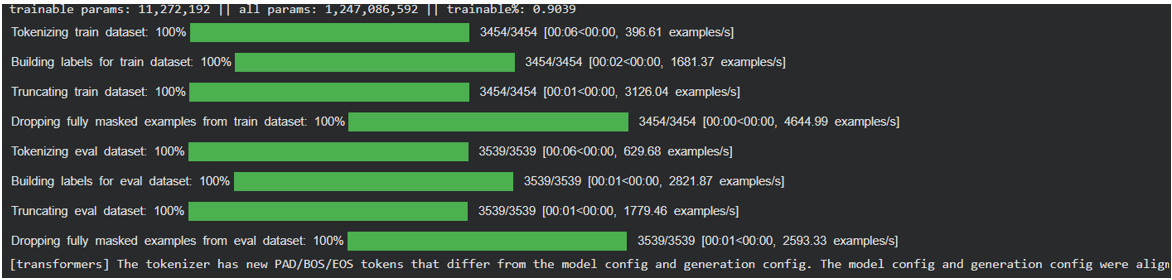

[A guide to training](https://huggingface.co/learn/llm-course/chapter7/6)

In [ ]:
# Save finetuned model to Drive 
path_to_finetuned_model = RESULTS_DIR / f"finetune_{DESCRIPTION}"
trainer.save_model(path_to_finetuned_model)
hf_tokenizer.save_pretrained(path_to_finetuned_model)
print(f"Model saved to: {path_to_finetuned_model}")

In [ ]:
path_to_finetuned_model = RESULTS_DIR / f"finetune_{DESCRIPTION}"
path_to_finetuned_model

In [ ]:
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)
path_to_finetuned_model = "hernandezb3/aimecon-base"

model = PeftModel.from_pretrained(base_model, path_to_finetuned_model)
hf_tokenizer = AutoTokenizer.from_pretrained(path_to_finetuned_model)

In [ ]:
path_to_finetuned_model = "hernandezb3/aimecon-best" #best prompt

# Testing

In [ ]:
DATA_SOURCE = "test" # train, dev, test

path_to_data = DATA_DIR / f"{DATA_SOURCE}.xlsx"
test_df = pd.read_excel(path_to_data)
test_df

In [ ]:
SAMPLE_SIZE = 30
sample = test_df.sample(n = SAMPLE_SIZE, ignore_index = True)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score

In [ ]:
# ---- Reuse model already in memory ----
model_inf = model
model_inf.eval()

hf_tokenizer.padding_side = "left"

# ---- Inference function ----
def predict_batch(texts, batch_size=32):
    predictions = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        prompt_texts = []

        for text in batch:
            messages = [
                {
                    "role": "user",
                    "content": prompt_case(
                        str(text),
                        prompt_dictionary[prompt_id]
                    )
                },
            ]

            prompt_texts.append(
                hf_tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
            )

        inputs = hf_tokenizer(
            prompt_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2000,
        ).to(model_inf.device)

        with torch.no_grad():
            outputs = model_inf.generate(
                **inputs,
                max_new_tokens=5,
                do_sample=False,
                pad_token_id=hf_tokenizer.eos_token_id,
            )

        input_len = inputs["input_ids"].shape[1]

        for out in outputs:
            answer = hf_tokenizer.decode(
                out[input_len:],
                skip_special_tokens=True
            ).strip()

            if answer.lower().startswith("yes"):
                predictions.append(1)

            elif answer.lower().startswith("no"):
                predictions.append(0)

            else:
                predictions.append(-1)
                print(f"Unexpected: '{answer}'")

        print(
            f"Batch {i // batch_size + 1} done — "
            f"{len(predictions)}/{len(texts)}"
        )

    return predictions

In [ ]:
# Take a smaller sample
SAMPLE_SIZE = 30

sample = test_df.sample(
    n=SAMPLE_SIZE,
    random_state=42,     # seed
    ignore_index=True
)

print(f"Sample size: {len(sample)}")


# ---- Run inference on sample only ----
print("Running inference...")

preds = predict_batch(
    sample["text"].tolist(),
    batch_size=32
)

labels = sample["code_human"].tolist()


# ---- Evaluate ----
print("\n=== Sample Test Results ===")

print(f"Accuracy:  {accuracy_score(labels, preds):.4f}")
print(f"Cohen's κ: {cohen_kappa_score(labels, preds):.4f}")

print("\nClassification Report:")

print(
    classification_report(
        labels,
        preds,
        target_names=["No (0)", "Yes (1)"]
    )
)

unexpected = sum(p == -1 for p in preds)

if unexpected:
    print(
        f"\nWarning: {unexpected} unexpected outputs "
        "(not Yes/No)"
    )

# More Info

**Videos**
- [3Blue1Brown: But what is a GPT?](https://www.youtube.com/watch?v=wjZofJX0v4M): a visual introduction to transformers and next-token prediction.
- [Andrej Karpathy: Let's build GPT, from scratch, in code](https://www.youtube.com/watch?v=kCc8FmEb1nY): builds a small GPT step by step

# Classification Error Metrics

In **classification**, the model predicts a **class**: 0 or 1, yes or no, spam or not spam. A prediction is either right or wrong, so we need different ways to measure how good a model is.

### 1. The example: a spam filter

Imagine a model that reads 20 emails and predicts whether each one is **spam (1)** or **not spam (0)**. We also know the true answer for each email.

- `actual` ($Y$): the true label
- `pred` ($\hat{Y}$): what the model predicted

In this problem, **spam is the positive class (1)**. "Positive" doesn't mean "good." It just means "the thing we're trying to detect."


In [ ]:
#pip install pandas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [13]:
TP_C = "#8FBF9F"   # sage green  - True Positive
TN_C = "#8EAFD1"   # dusty blue  - True Negative
FP_C = "#E3C08D"   # soft sand   - False Positive
FN_C = "#D99A9A"   # dusty rose  - False Negative
GREY = "#E3E3E3"   # light grey  - "not spam" boxes

In [ ]:
subjects = [
    "WIN a free iPhone!!!", "Team meeting at 3pm", "Your invoice #4821", "Claim your prize now",
    "Lunch tomorrow?", "Cheap meds, no prescription", "Project update", "You've been selected!",
    "Mom's birthday plans", "Limited offer: 90% off", "Re: homework question", "Urgent: verify your account",
    "Class cancelled today", "Hot singles near you", "Library book due", "Make $5000 a week from home",
    "Weekend hiking trip", "Your package is waiting (click)", "Exam schedule", "FREE gift card inside",
]
actual = [1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
pred   = [1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1]
df = pd.DataFrame({"subject": subjects, "actual": actual, "pred": pred})
df

The chart below shows each email as a box: the top row is the truth, the bottom row is the model's prediction. Red boxes = spam (1), grey boxes = not spam (0).

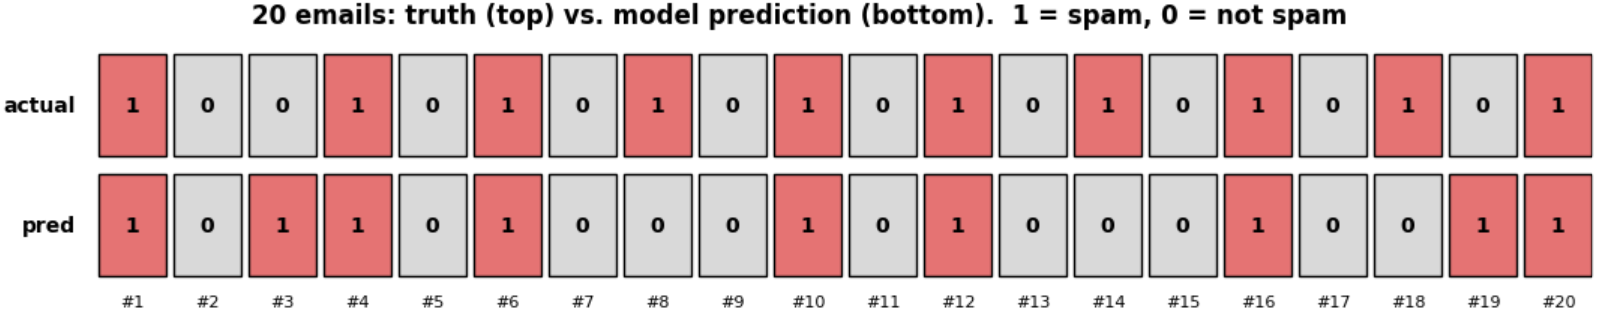

### 2. TP, FP, TN, FN: the four possible outcomes

Every prediction falls into exactly one of four boxes. **Memorize this:**

| | Model says **spam (1)** | Model says **not spam (0)** |
|---|---|---|
| **Really spam (1)** | **True Positive (TP)**: caught the spam ✓ | **False Negative (FN)**: spam slipped into the inbox ✗ |
| **Really not spam (0)** | **False Positive (FP)**: a real email sent to spam ✗ | **True Negative (TN)**: real email left alone ✓ |

A trick to read the names:
- The **second word** (Positive / Negative) is **what the model predicted**.
- The **first word** (True / False) is **whether the model was right**.

So a *False Positive* means "the model said positive, and it was wrong."

In [8]:
def outcome(a, p):
    if a == 1 and p == 1: return "TP"
    if a == 0 and p == 0: return "TN"
    if a == 0 and p == 1: return "FP"
    return "FN"

df["outcome"] = [outcome(a, p) for a, p in zip(actual, pred)]
df

,subject,actual,pred,outcome
0,WIN a free iPhone!!!,1,1,TP
1,Team meeting at 3pm,0,0,TN
2,Your invoice #4821,0,1,FP
3,Claim your prize now,1,1,TP
4,Lunch tomorrow?,0,0,TN
5,"Cheap meds, no prescription",1,1,TP
6,Project update,0,0,TN
7,You've been selected!,1,0,FN
8,Mom's birthday plans,0,0,TN
9,Limited offer: 90% off,1,1,TP


### 3. The confusion matrix

The **confusion matrix** counts how many predictions fall in each of the four boxes and arranges them in a 2 × 2 grid.

> **Be careful:** different packages arrange the grid differently. In `sklearn`, **rows are the actual class** and **columns are the predicted class**, with class 0 first. Always check the documentation.

In `sklearn`'s layout:

|  | predicted 0 | predicted 1 |
|---|---|---|
| **actual 0** | TN (top left) | FP (top right) |
| **actual 1** | FN (bottom left) | TP (bottom right) |

**How to read it:** look at the **diagonal** first (top left and bottom right). Those are the correct predictions. A good model has big numbers on the diagonal and small numbers off it.

In [ ]:
#pip install scikit-learn

In [11]:
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score,
                             balanced_accuracy_score, cohen_kappa_score)

In [12]:
cm = confusion_matrix(actual, pred)
print(cm)

tn, fp, fn, tp = cm.ravel()      # ravel() flattens the grid in the order TN, FP, FN, TP
print(f"\nTN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

[[8 2]
 [3 7]]

TN = 8, FP = 2, FN = 3, TP = 7


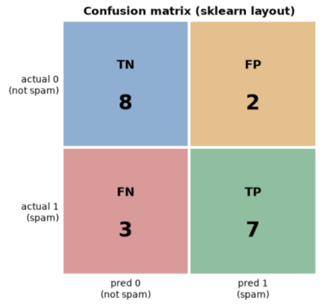

### 4. Accuracy

**Accuracy** is the share of all predictions that were correct:

$$\text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{\text{correct predictions}}{\text{all predictions}}$$

Formally, if $\hat{y}_i$ is the prediction and $y_i$ the truth for sample $i$:

$$\text{accuracy}(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^{n} 1(\hat{y}_i = y_i)$$

where $1(\cdot)$ is 1 when the prediction is correct and 0 otherwise.

Accuracy is easy to understand, but it **assumes the classes are roughly balanced**. Section 9 shows how it can be very misleading when they aren't.

In [15]:
my_accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"By hand : ({tp} + {tn}) / {tp + tn + fp + fn} = {my_accuracy:.2f}")
print(f"sklearn : {accuracy_score(actual, pred):.2f}")

By hand : (7 + 8) / 20 = 0.75
sklearn : 0.75


### 5. Precision and recall

Both focus on **one class** (here, spam = 1), but they ask different questions.

**Precision: "When the model says spam, how often is it right?"**

$$\text{precision} = \frac{TP}{TP + FP}$$

High precision = few false alarms (few real emails wrongly sent to spam).

**Recall: "Of all the real spam, how much did the model catch?"**

$$\text{recall} = \frac{TP}{TP + FN}$$

High recall = few misses (little spam slips through). Recall is also called **sensitivity** or the **true positive rate**.

**How to remember which is which, using the confusion matrix:**
- **Recall → Rows.** Look along the **actual 1 row**: of everything that was really spam (TP + FN), how much was caught (TP)?
- **Precision → columns.** Look down the **predicted 1 column**: of everything the model called spam (TP + FP), how much really was spam (TP)?

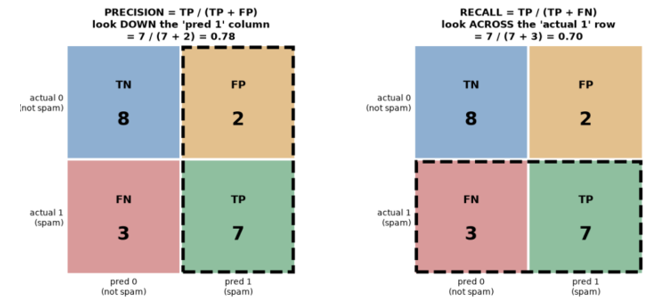

In [18]:
# Precision and recall for the spam class (1), by "hand"
precision_1 = tp / (tp + fp)
recall_1 = tp / (tp + fn)
print(f"Class 1 (spam):     precision = {precision_1:.2f}   recall = {recall_1:.2f}")

# You can switch the formulas around for the not-spam class (0):
# "positive" now means "not spam", so TN plays the role of TP
precision_0 = tn / (tn + fn)
recall_0 = tn / (tn + fp)
print(f"Class 0 (not spam): precision = {precision_0:.2f}   recall = {recall_0:.2f}")

# Check with sklearn
print(f"\nsklearn, class 1: precision = {precision_score(actual, pred):.2f}   recall = {recall_score(actual, pred):.2f}")

Class 1 (spam):     precision = 0.78   recall = 0.70
Class 0 (not spam): precision = 0.73   recall = 0.80

sklearn, class 1: precision = 0.78   recall = 0.70


**In words, for this spam filter:**
- **Precision = 0.78:** when the filter flags an email as spam, it's right 78% of the time (7 out of 9). The other 2 were real emails sent to the spam folder.
- **Recall = 0.70:** the filter caught 70% of the real spam (7 out of 10). The other 3 spam emails reached the inbox.

| | Meaning | Spam filter example |
|---|---|---|
| **High recall, low precision** | Catches almost all positives (few FN), but raises many false alarms (many FP) | Almost no spam gets through, but many real emails end up in spam |
| **Low recall, high precision** | Misses many positives (many FN), but when it says positive it's almost always right (few FP) | Everything in the spam folder really is spam, but lots of spam still reaches the inbox |

### 6. F1 score

The **F1 score** combines precision and recall into a single number:

$$F1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

This is the **harmonic mean**, which is pulled toward the **smaller** of the two values. So a model can only get a high F1 if **both** precision and recall are high. If one of them is terrible, F1 is low too, even when accuracy looks fine. That makes F1 especially useful for imbalanced data.

The chart compares F1 with a simple average when recall is fixed at 0.9 and precision varies.

In [19]:
f1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1)
print(f"By hand : 2 x ({precision_1:.2f} x {recall_1:.2f}) / ({precision_1:.2f} + {recall_1:.2f}) = {f1:.2f}")
print(f"sklearn : {f1_score(actual, pred):.2f}")

By hand : 2 x (0.78 x 0.70) / (0.78 + 0.70) = 0.74
sklearn : 0.74


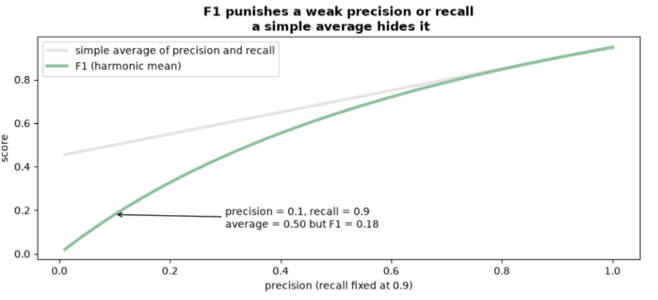

### 7. The classification report

`classification_report` computes precision, recall and F1 for **every class** at once:

In [21]:
print(classification_report(actual, pred, target_names=["not spam (0)", "spam (1)"]))

              precision    recall  f1-score   support

not spam (0)       0.73      0.80      0.76        10
    spam (1)       0.78      0.70      0.74        10

    accuracy                           0.75        20
   macro avg       0.75      0.75      0.75        20
weighted avg       0.75      0.75      0.75        20



How to read it:

| Part | Meaning |
|---|---|
| Rows `not spam (0)` and `spam (1)` | Precision, recall and F1 for each class, the same numbers we computed by hand |
| `support` | How many samples **actually** belong to that class (10 and 10 here) |
| `accuracy` | Overall accuracy (one number for the whole model) |
| `macro avg` | Simple average over the classes: every class counts equally |
| `weighted avg` | Average weighted by `support`: bigger classes count more |

When the classes are imbalanced, the **macro average** is usually more honest, because the small class isn't drowned out by the big one.

### 8. The precision vs. recall trade-off (thresholds)

Most classifiers don't directly output 0 or 1. They output a **score** or probability (for example, "this email is 83% likely to be spam"), and a **threshold** turns it into a class:

$$\hat{y} = 1 \text{ if score} \geq \text{threshold, otherwise } 0$$

The default threshold is usually 0.5, but you can move it:
- **Lower threshold** → more emails flagged as spam → **recall goes up**, but more false alarms, so **precision goes down**.
- **Higher threshold** → fewer emails flagged → **precision goes up**, but more spam is missed, so **recall goes down**.

The demo below uses 400 emails with simulated spam scores.

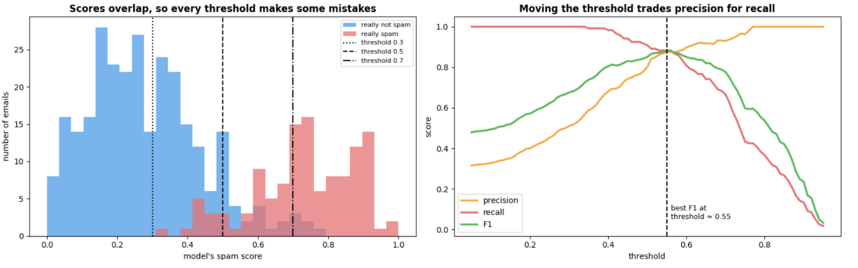

**Which one matters more depends on the cost of each mistake:**

| Situation | Worse mistake | Prioritize |
|---|---|---|
| Spam filter | FP: an important real email disappears into spam | **Precision** |
| Disease screening test | FN: a sick patient is told they're healthy | **Recall** |
| Fraud detection | FN: fraud goes unnoticed (but too many FP annoys customers) | Recall, balanced with precision |

### Resources

- [scikit-learn: model evaluation guide](https://scikit-learn.org/stable/modules/model_evaluation.html): accuracy, precision, recall, F1, balanced accuracy, kappa and more.
- [scikit-learn: `classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [GeeksforGeeks: confusion matrix in machine learning](https://www.geeksforgeeks.org/confusion-matrix-machine-learning/)
- [Classification report explained (Medium)](https://medium.com/@kennymiyasato/classification-report-precision-recall-f1-score-accuracy-16a245a437a5)
- [Wikipedia: sensitivity and specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity)

# Forward Propagation

**Forward propagation** is how a neural network turns an input into a prediction: the input flows **forward** through layers of **weights**, and a prediction comes out the other end.

$$\text{Input (information)} \;\rightarrow\; \text{Weights (knowledge)} \;\rightarrow\; \text{Output (prediction)}$$

An LLM is no different. When our fine-tuned model reads an utterance and answers **"y"** or **"n"**, it is doing forward propagation: a long chain of **dot products**. 

* **Input data:** The information the neural network starts from. These are measurements or observations from the real world (Input Data/Layer). 

* **Prediction:** The network's answer after it has processed the input. The output generated by the nn

* **Prediction error:** A prediction is a best guess, so it won't always be right. Comparing the prediction with what really happened gives the error: a measure of how far off the network was.

* **Learning from mistakes:** The network uses the error to decide how to change its weights. If it guessed too high, the weights are adjusted so the next guess is lower; if it guessed too low, they're adjusted so the next guess is higher.

* **Updating the weights:** Training repeats this loop many times: input → prediction → error → weight update. Each pass nudges the weights a little, so the error shrinks and the network makes better predictions the next time it sees similar data.

* **Dot product (a weighted sum)**: with multiple prediction we need a more sophisticated way to combine information from multiple inputs, we need the dot product. 
     * with multiple inputs we have to sum their predictions, but each input will by multiplied by its own weight. 

Detour: Dot product
 * Lets say two vectors with three element each
 * 1 by 3 vector --> one column three rows
 * 3 by 1 vector --> three rows one column
   * [1 by 3] X  [3 by 1] = [1 by 1]
   > The requirement for matrix multiplication is that the number of columns of the first matrix must be equal to the number of rows of the second matrix.

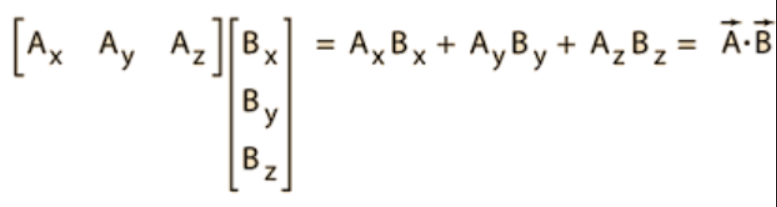

## Predictions on Predictions

Adding more weight matrices creates **hidden layers**: intermediate results that become the input to the next layer. A network with **one hidden layer** therefore has **two weight matrices**:

* one connecting the **i**nput to the **h**idden layer (`ih_weights`)
* one connecting the **h**idden layer to the **p**rediction, or output, layer (`hp_weights`)

**1: Draw an empty graph**

Start with the structure: 3 input nodes, 4 hidden nodes and 1 output node. 
Every node is connected to **every** node in the next layer, and every line has its own **weight**.

- Layer 0 → layer 1: 3 × 4 = **12 weights**
- Layer 1 → layer 2: 4 × 1 = **4 weights**

ih_weights
* are input to hidden, input layers to hidden layers

hh_weights
h1h2
* we dont have it here but hidden to hidden layers

hp_weights
* are hidden layers to prediction, hidden to prediction

(The letter style (ih, hh, hp) gets confusing as soon as there are two or more hidden layers, because hh doesn't say which hidden layers it connects. That's why most code uses the numbered style: weights_0_1, weights_1_2, weights_2_3,)


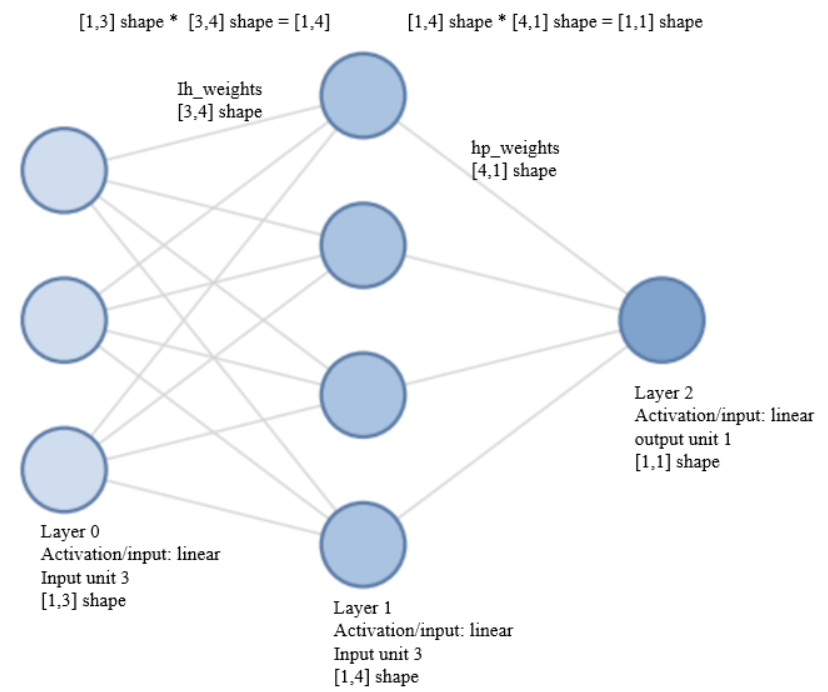

**2: Input Layer and Weights**

Our input is:

$$\text{layer\_0} = [0,\ 1,\ 1]$$



Our weights

Add the weights and compute the dot product

The weights from layer 0 to layer 1 are stored in a matrix with **one row per input** and **one column per hidden node**:

| | → hidden 1 | → hidden 2 | → hidden 3 | → hidden 4 |
|---|---|---|---|---|
| **from input 1** (= 0) | 0.5 | −0.3 | 0.8 | −0.6 |
| **from input 2** (= 1) | 0.2 | −0.4 | 0.6 | 0.1 |
| **from input 3** (= 1) | 0.3 | 0.1 | −0.2 | −0.5 |

Each **column** is the set of weights on the three lines going **into one hidden node**.

To get a hidden node's value: **multiply each input by the weight on its line, then add the three results.** That's the **dot product** of the input with that column.

How many nodes?
- it depends, the input layer nodes are decided by the data
- the output layer node is decided by the task
- the hidden layers, you as th designer decide the hidden layers structure

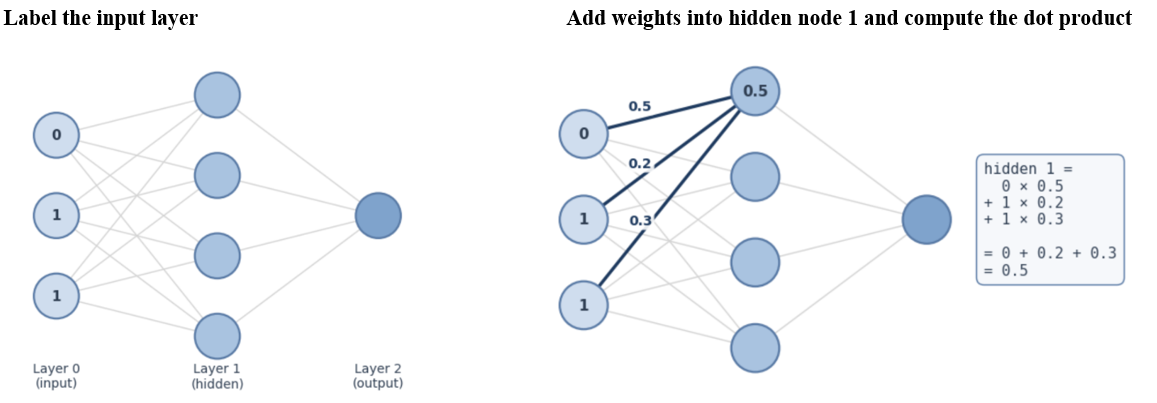

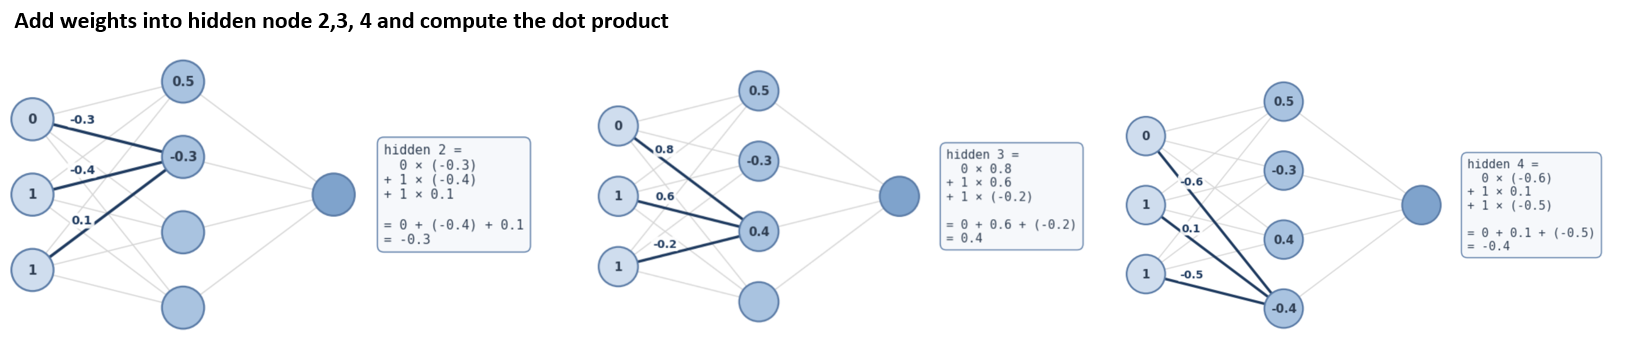

Notice that **input 1 is 0**, so its weights (0.5, −0.3, 0.8, −0.6) never matter here: 0 × anything = 0.

All four dot products together give layer 1:

| Hidden node | Calculation | Value |
|---|---|---|
| 1 | 0 × 0.5 + 1 × 0.2 + 1 × 0.3 | **0.5** |
| 2 | 0 × (−0.3) + 1 × (−0.4) + 1 × 0.1 | **−0.3** |
| 3 | 0 × 0.8 + 1 × 0.6 + 1 × (−0.2) | **0.4** |
| 4 | 0 × (−0.6) + 1 × 0.1 + 1 × (−0.5) | **−0.4** |

NumPy's `.dot()` computes all four at once. The **golden rule** of shapes: `[1, 3] · [3, 4] = [1, 4]` (the middles match, the outsides give the result).

**3. Apply ReLU**

**ReLU** keeps positive numbers as they are and turns negative numbers into 0:

$$\text{ReLU}(x) = \max(0, x)$$

| Hidden node | Before ReLU | After ReLU |
|---|---|---|
| 1 | 0.5 | **0.5** |
| 2 | −0.3 | **0** |
| 3 | 0.4 | **0.4** |
| 4 | −0.4 | **0** |

* ReLU is an activation functions, it tells nodes how much of its signal should be passed forward to the next layers. 
* Activation fuctions add nonlinearity, which lets the network learn or complicated patterns

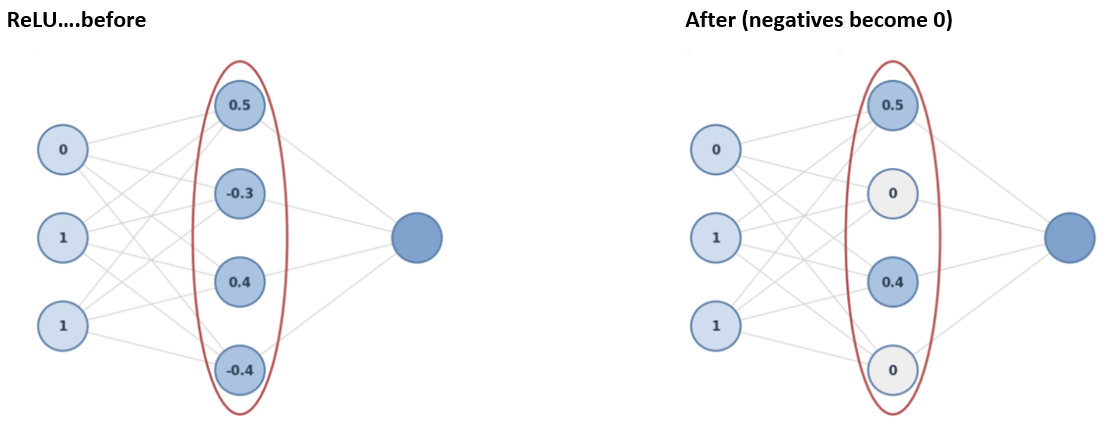

ReLU decides **which hidden nodes speak up** for a given input:
  * Positive value: "this pattern is present, this strongly," so it passes through.
  * Negative value: "this pattern isn't here," so it's switched off (0) and contributes nothing.
so,
* Different inputs switch on different nodes, so the network effectively uses a different combination of features for different inputs. 
Note that `relu` is only used between hidden layers - you don't use `relu` going to `layer_2` (the output layer). We will eventually use different activation functions there.

**4. From layer 1 to layer 2**

Same thig again: **multiply each hidden value (after ReLU) by the weight on its line to the output, then add.**

| Hidden node (after ReLU) | × weight to output | = contribution |
|---|---|---|
| 0.5 | × 0.7 | 0.35 |
| 0 | × (−0.5) | 0 |
| 0.4 | × 0.9 | 0.36 |
| 0 | × 0.3 | 0 |
| | **Sum** | **0.71** |

Shapes: `[1, 4] · [4, 1] = [1, 1]`, a single prediction.

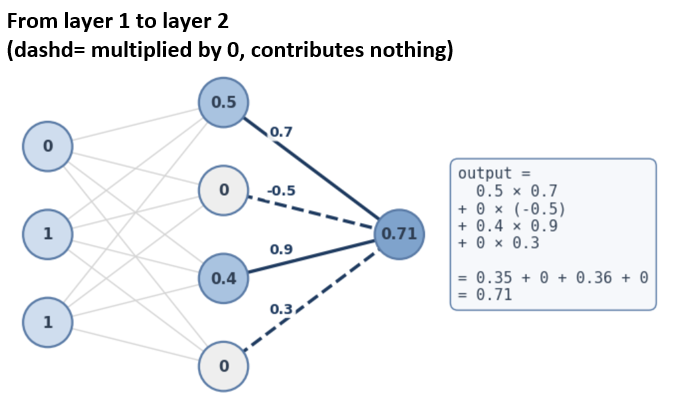

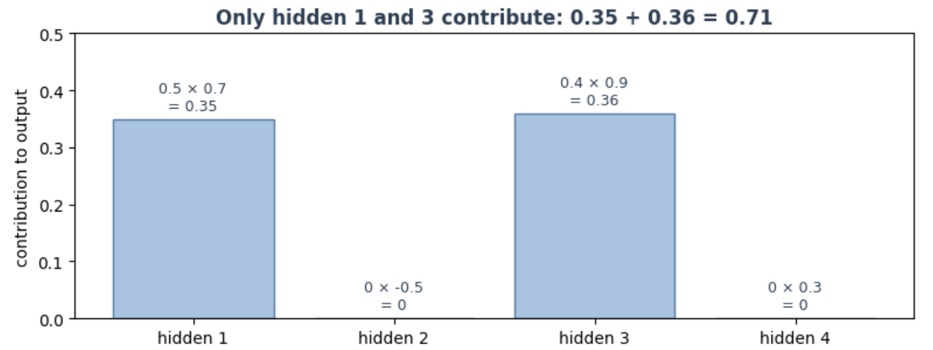

**5. Compare with the target**

The network predicts **0.71**, but the correct answer (the **target**) is **1**.

$$\text{error} = \text{prediction} - \text{target} = 0.71 - 1 = -0.29$$

The weights here were made up, so the prediction is off. **Backpropagation** (next) uses this error to adjust every weight a little, so the next prediction gets closer to the target.

Note that the switched-off nodes (hidden 2 and 4) also **won't be updated** for this input: their value was 0, so changing their weights wouldn't have changed the prediction. With a different input, they may become positive and start contributing.

### Resources

**Interactive and beginner-friendly**
- [Google ML Crash Course: Nodes and hidden layers](https://developers.google.com/machine-learning/crash-course/neural-networks/nodes-hidden-layers): builds a hidden layer step by step, with an interactive exercise to click each node and see its calculation.
- [Google ML Crash Course: Activation functions](https://developers.google.com/machine-learning/crash-course/neural-networks/activation-functions): why we need ReLU and other activations.
- [TensorFlow Playground](https://playground.tensorflow.org/): build a small network in the browser, change layers and activations, and watch it learn.

**Videos**
- [3Blue1Brown: But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk): a visual introduction to layers, weights, biases and activations.

**Deeper reading**
- [Dive into Deep Learning, 5.3: Forward propagation, backward propagation and computational graphs](https://d2l.ai/chapter_multilayer-perceptrons/backprop.html): the forward pass step by step, and how it connects to backpropagation.
- [Stanford CS231n: Neural Networks Part 1](https://cs231n.github.io/neural-networks-1/): neurons, layers, activation functions and the matrix form of the forward pass.

LLM Visualization
- [LLM Visual](https://bbycroft.net/llm)
- [Transformer Explained](https://poloclub.github.io/transformer-explainer/)

# BackPropagation, The Blaming Game

Use prediction error as a feedback signal! If weights just overestimated, update the weights so that the prediction is more accurate!

* **Backward pass:** gradients show how each trainable weight should change to make the loss smaller.

* Updating the weights is all about making more accurate prediction.
   * Learning in a neural network is largely about **error attribution**: figuring out how much each weight contributed to the model’s error. 
   We can think of this as the neural network’s “blame game.” More formally, this involves computing gradients, which are then used by gradient descent to update the weights.
      * For each weight, the model calculates a number that tells us how the error would change if that weight changed. The sign tells us whether the weight should increase or decrease, while the magnitude tells us how strongly that weight is related to the error.
      * The model then uses this information, together with the learning rate, to adjust each weight in the direction that reduces the error. Repeating this process over many iterations is how the network gradually learns better weights and improves its predictions

Not all weights are updating
* As the input moves through the network, each weight helps create the final prediction.
* A weight should only be updated if it actually contributed to that prediction. The amount it changes also depends on how large the input was.
* This is error attribution: figuring out which weights contributed to the error and how much each one should be adjusted.

Learning Rate
* The learning rate controls how big each step is when we update the weights. We usually want to take small, controlled steps so the model does not learn too quickly.
* If the steps are too large, the model can skip over a good solution. By moving more slowly, the model can explore the solution space more carefully and gradually move toward the best set of weights.
  - A good analogy is standing on a hillside in fog and wanting to get to the bottom (the lowest loss). The gradient is like feeling the slope under your feet: it tells us which way is downhill. Every weight gets its own gradient. Learning rate is how fast or slow we go

### Different Type of Gradient Descent

The main difference between these methods (below) is how many examples the model looks at before updating its weights.
1. **Stochastic Gradient Descent (SGD):** The model looks at one training example at a time and updates the weights after every example. This means the weights are updated very frequently.

2. **Full-Batch Gradient Descent:** The model looks at the entire training dataset, calculates the average gradient across all examples, and then updates the weights once.

3. **Mini-Batch Gradient Descent:** The model looks at a small group of examples at a time, called a batch. For example, with a batch size of 32, the model processes 32 examples, calculates their average gradient, and then updates the weights. It continues doing this batch by batch until it has gone through the entire dataset.


**1. Recap the forward pass**

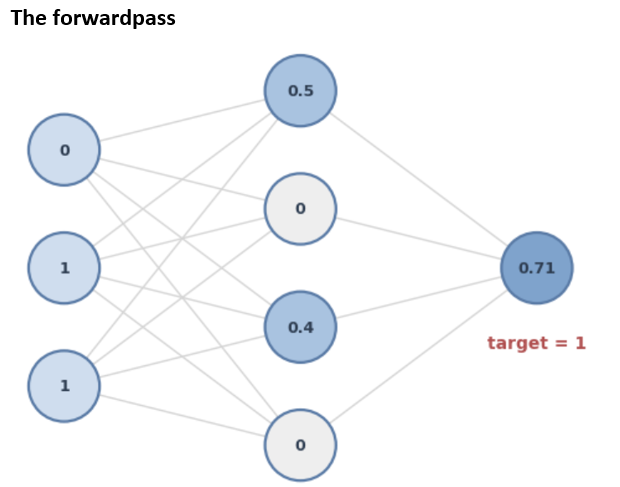

Same network, same input, same weights as before:

**2. Measure the error at the output**

Two numbers describe the mistake:

**The delta** (also called the **raw error**): how far off the prediction was, *with a direction*.

$$\delta_{\text{out}} = \text{prediction} - \text{target} = 0.71 - 1 = -0.29$$

- Negative delta → the prediction was **too low** → the weights need to push the output **up**.
- Positive delta → the prediction was **too high** → push the output **down**.

**The error** (here, squared error): how big the mistake is, always positive. This is the number training tries to make as small as possible.

$$\text{error} = (\text{prediction} - \text{target})^2 = (-0.29)^2 = 0.0841$$

> The delta is the slope of the squared error (up to a factor of 2, which is usually folded into the learning rate). That's why it tells us the **direction** to move.

**3. The Blame game**

How much should each weight from the hidden layer to the output change? It depends on **two things**:

1. **The output's delta** (−0.29): how wrong the prediction was, and in which direction.
2. **The hidden value on that line**: how much that weight actually affected the prediction. A weight multiplied by 0 had **no effect**, so it gets **no blame**.

$$\text{weight delta} = \text{hidden value} \times \delta_{\text{out}}$$

| Hidden node (after ReLU) | × output delta | = weight delta |
|---|---|---|
| 0.5 | × (−0.29) | **−0.145** |
| 0 | × (−0.29) | **0** (no blame) |
| 0.4 | × (−0.29) | **−0.116** |
| 0 | × (−0.29) | **0** (no blame) |

The gradient: how much the weight need to change to affect the loss
* The gradient for the first node is -0.145
    - It is negative meaning we need to increase the the weight would lower the loss

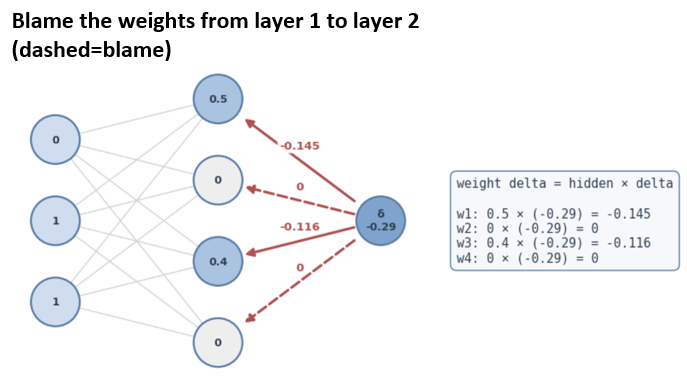

**4. Send the error back to the hidden layer**

Now the key idea of **back**propagation: to fix the weights **before** the hidden layer, we first need to know how much each **hidden node** contributed to the error.

Each hidden node's delta is the output's delta, sent **backwards along the same weight** it used in the forward pass:

$$\delta_{\text{hidden}} = \delta_{\text{out}} \times \text{weight to the output}$$

It's the forward pass in reverse: in the forward pass we multiplied **forward** by the weights, now we multiply the error **backward** by the same weights.

| Hidden node | Output delta × weight | Hidden delta (before ReLU) |
|---|---|---|
| 1 | (−0.29) × 0.7 | −0.203 |
| 2 | (−0.29) × (−0.5) | +0.145 |
| 3 | (−0.29) × 0.9 | −0.261 |
| 4 | (−0.29) × 0.3 | −0.087 |

* A **negative** hidden delta means "this node should have been **bigger**" to push the prediction up. 
* Node 2's delta is **positive** because its weight to the output is negative: it should have been **smaller**.

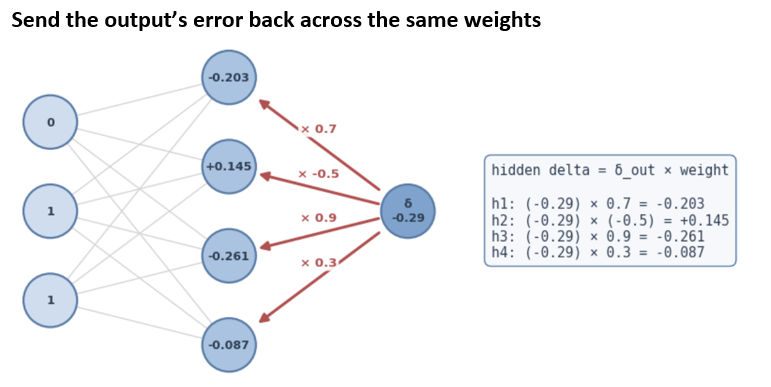

**5. ReLU decides which hidden nodes get blamed**

Remember that ReLU switched off hidden nodes 2 and 4 in the forward pass (they were negative, so they became 0). 
A switched-off node has **no effect** on the prediction: changing it slightly would still give 0 after ReLU. So it gets **no blame**.

This is done by multiplying by the **slope of ReLU**:
- **1** where the node was **on** (positive) → the delta passes through unchanged
- **0** where the node was **off** → the delta is stopped

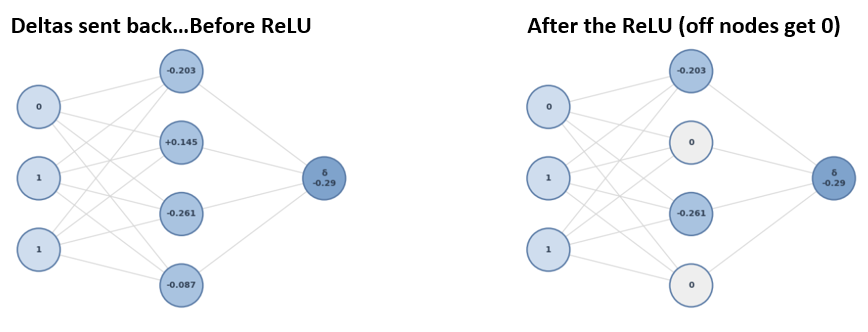

**6. Blame the weights between layr 0 and layer 1**

Same rule as step 3, one layer further back:

$$\text{weight delta} = \text{input value} \times \delta_{\text{hidden}}$$

Each of the 12 weights gets: **(the input at the start of its line) × (the delta of the hidden node at the end of its line)**.

Only **4 of the 12** weights get blamed:
- Input 1 was **0**, so its weights had no effect → no blame (its whole row is 0).
- Hidden nodes 2 and 4 were **switched off** → no blame (their columns are 0).

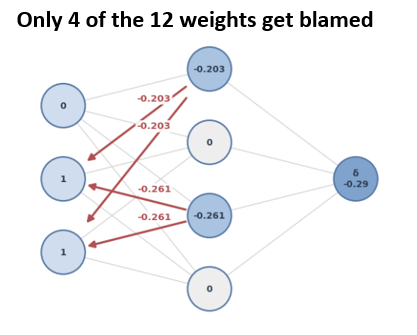

**7. Updat all the weights**

Now every weight takes a small step **against** its weight delta:

$$\text{new weight} = \text{old weight} - \alpha \times \text{weight delta}$$

The **learning rate** $\alpha$ (alpha) controls how big the step is. We use $\alpha = 0.1$.

Why **minus**? The weight delta points in the direction that makes the error **bigger**, so we step the opposite way. In our example the deltas are negative (the prediction was too low), so subtracting them makes the weights **bigger**, which pushes the prediction **up**.

**Layer 0 → layer 1:** only the 4 blamed weights change, each by +0.0203 (to hidden 1) or +0.0261 (to hidden 3).

**Layer 1 → layer 2:** only the 2 blamed weights changed, h1 by +0.0145 to layer2, h3 by +0.0116 layer2.

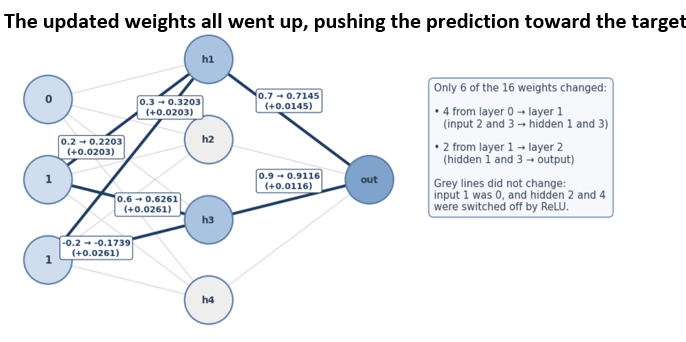

**8. Run the forward pass again. Did it improve**

With the updated weights, the same input gives a new prediction:\

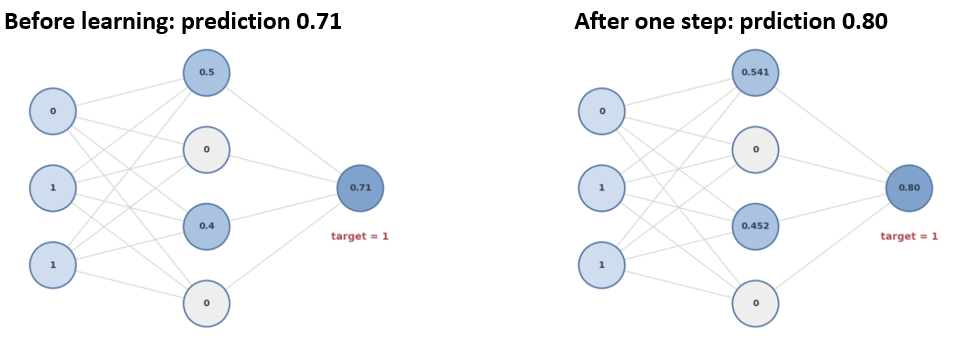

### See the whole process


A very simple one

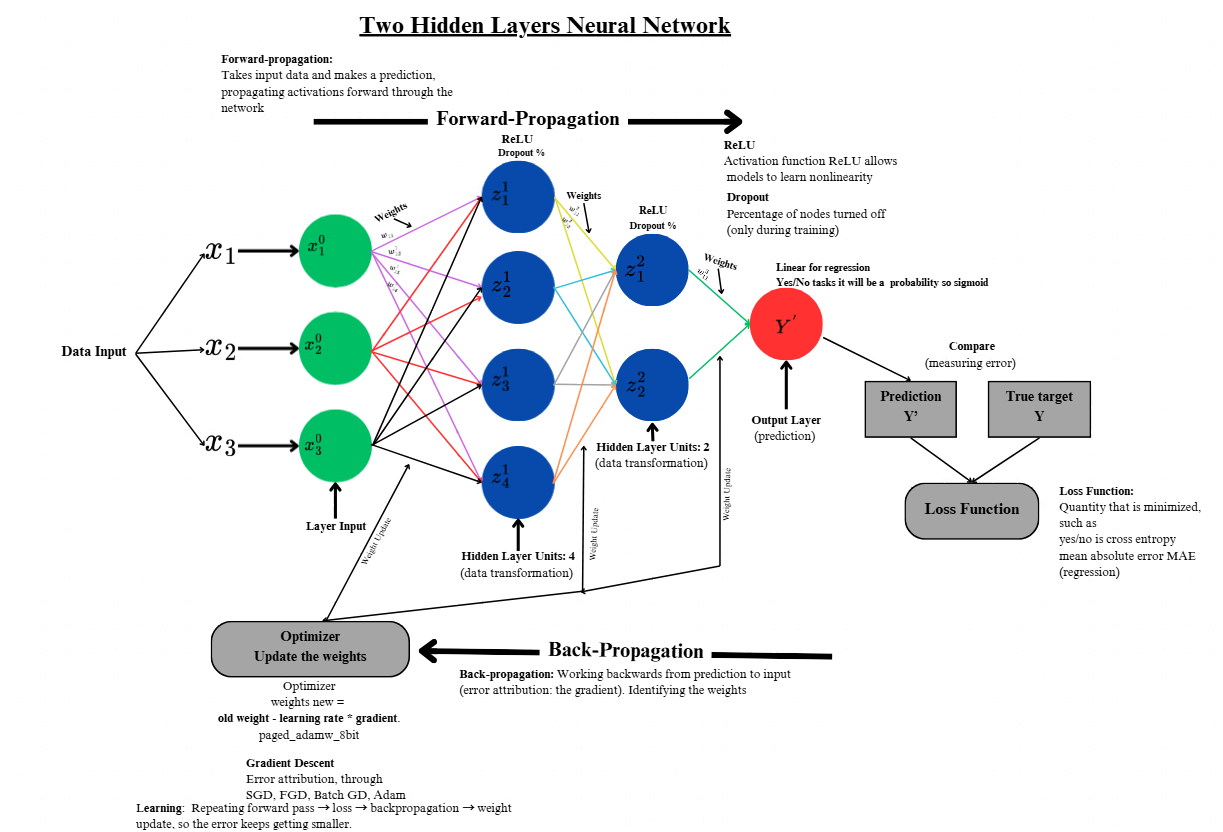

# LLM, Training and Log Loss (Cross-Entropy)

An LLM is trained to do one thing: **predict the next token**. 
 * Log loss Cross-entropy is the number that tells the model how well it did. 
 * "log loss" usually refers to the binary case (two classes, like y/n).

**Lets do an Example**

### 1. The model gives a score to every token

At each position in the text, the LLM outputs one number for **every token in its vocabulary**. 
  * These raw scores are called **logits**. A higher logit means "I think this token is more likely to come next."

Real vocabularies have tens of thousands of tokens. To keep things readable, imagine a vocabulary of just 3 tokens. At the position where our y/n answer goes, the model outputs:

| Token | "y" | "n" | other |
|---|---|---|---|
| Logit (raw score) | 2.0 | 0.75 | 0.06 |

Logits can be any number (even negative), so they are **not** probabilities yet.

### 2. Softmax turns the scores into probabilities

The **softmax** function turns the logits into probabilities that are all positive and add up to 1:

$$q_i = \frac{e^{\text{logit}_i}}{\sum_j e^{\text{logit}_j}}$$

| Token | "y" | "n" | other | Sum |
|---|---|---|---|---|
| $e^{\text{logit}}$ | 7.39 | 2.12 | 1.06 | 10.57 |
| Probability $q$ | **0.70** | 0.20 | 0.10 | 1.00 |

This is the model's **prediction**: a probability for every possible next token.



### 3. Cross-entropy compares the prediction with the truth

From the training data, we know the correct next token. Say it's **"y"**. We can write the truth as a distribution $p$ too:

| Token | "y" | "n" | other |
|---|---|---|---|
| Truth $p$ | 1 | 0 | 0 |
| Prediction $q$ | 0.70 | 0.20 | 0.10 |

**Cross-entropy** measures how far the prediction $q$ is from the truth $p$:

$$H(p, q) = -\sum_i p_i \ln q_i$$

Because the truth is 1 for the correct token and 0 everywhere else, every term except one disappears:

$$H(p, q) = -\big[1 \cdot \ln(0.70) + 0 \cdot \ln(0.20) + 0 \cdot \ln(0.10)\big] = -\ln(0.70) = 0.36$$

So in LLM training, cross-entropy is simply:

$$\boxed{\text{loss} = -\ln q(\text{correct token})}$$

**Minus the log of the probability the model gave to the correct token.** In classification, this is called **log loss**.

### 4. How the loss reacts

The loss depends only on how much probability the model gave to the correct token:

| Probability given to the correct token | Loss = $-\ln q$ | Meaning |
|---|---|---|
| 0.99 | 0.01 | Confident and right: almost no loss |
| 0.90 | 0.11 | Good |
| 0.50 | 0.69 | Unsure: a coin flip |
| 0.10 | 2.30 | Mostly wrong: big loss |
| 0.01 | 4.61 | Confident and wrong: huge loss |

Two things make this a good training signal:

- **It never stops rewarding improvement.** Going from 0.90 to 0.99 still lowers the loss, so the model keeps becoming more confident in correct answers.
- **It punishes confident mistakes the most.** As the probability of the correct token approaches 0, the loss shoots toward infinity. A model that says 99% "n" when the answer is "y" pays far more than a model that was unsure.







### 5. How cross-entropy changes the model

First, what a gradient is?
* A gradient answers one question for each number in the model: "If I increase this number a little, does the loss go up or down, and by how much?
  * Remember the sign tells the direction. Positive mean increasing this number, makes th loss higher, worse?
  * Negative means incrasing it make the los better (lower)
  * Size tells how strongly this number affects the loss. 

* A good analogy is standing on a hillside in fog and wanting to get to the bottom (the lowest loss). The gradient is like feeling the slope under your feet: it tells us which way is downhill. Every weight gets its own gradient. 

During the backward pass, the gradient of the cross-entropy with respect to the logits turns out to be very simple:

$$\frac{\partial \text{loss}}{\partial \text{logit}_i} = q_i - p_i$$

For our example:

| Token | "y" (correct) | "n" | other |
|---|---|---|---|
| $q - p$ | 0.70 − 1 = **−0.30** | 0.20 − 0 = **+0.20** | 0.10 − 0 = **+0.10** |

Lets expand this

| Token | Model said $q$ | Truth $p$ | Gradient $q - p$ | What it means |
|---|---|---|---|---|
| "y" (correct) | 0.70 | 1 | **−0.30** | Negative: raising this logit would **lower** the loss |
| "n" | 0.20 | 0 | **+0.20** | Positive: raising this logit would **raise** the loss |
| other | 0.10 | 0 | **+0.10** | Positive, but smaller |

What is the optimizer?
- The optimizer is the rule that used the gradient to actually change the numbers. The simplest optimizer (plain gradient descent) is:
     
     * new value = old value - learning rate x gradient
       - The minus sign here is the key
           - the gradient points uphill (toward a higher loss), so we step the opposite way, downhill.
           - Negative gradient (like "y") → minus a negative → the value goes up.
           - Positive gradient (like "n") → the value goes down.

Lets do  learning rate of 1.00 (this is extremely large to make the change visible):

| Token | Old logit | Gradient | New logit = old − 1.0 × gradient |
|---|---|---|---|
| "y" | 2.00 | −0.30 | 2.00 + 0.30 = **2.30** ↑ |
| "n" | 0.75 | +0.20 | 0.75 − 0.20 = **0.55** ↓ |
| other | 0.06 | +0.10 | 0.06 − 0.10 = **−0.04** ↓ |

Now run softmax and cross-entropy again on the new logits:

| | Before | After one step |
|---|---|---|
| Probability of "y" | 0.70 | **0.79** |
| Loss = −ln q("y") | 0.36 | **0.24** |






So,
 optimizer moves in the **opposite** direction of the gradient:
- the logit of the **correct** token goes **up** (its gradient is negative), and
- the logits of the **wrong** tokens go **down**, more for the ones the model wrongly favored.

The worse the prediction, the bigger these numbers, so the model makes bigger corrections when it's more wrong. With LoRA, these gradients flow back through the frozen model and update only the A and B matrices.

### 5a. Detour: Learning Rate

In step 5, the optimizer updated each logit with:

$$\text{new} = \text{old} - \text{learning rate} \times \text{gradient}$$

The **gradient** says **which direction** to move. The **learning rate** says **how big a step** to take in that direction. It's one of the most important settings in training.

**Analogy:** walking down a foggy hill. The gradient is the slope you feel under your feet. The learning rate is your stride length:
- **Tiny strides:** safe, but it takes forever to reach the bottom.
- **Huge strides:** you can jump right over the valley and land higher up on the other side.
- **Good strides:** you get down quickly without overshooting.

#### The same example with different learning rates

Starting from the same logits (2.00, 0.75, 0.06) and the same gradient (−0.30, +0.20, +0.10), one step gives:

| Learning rate | New logit for "y" | P("y") after one step | Loss after one step |
|---|---|---|---|
| (before) | 2.00 | 0.70 | 0.36 |
| 0.1 | 2.03 | 0.71 | 0.34 |
| 1.0 | 2.30 | 0.79 | 0.24 |
| 10 | 5.00 | 0.996 | 0.005 |

A big learning rate looks great here, but this is **one example**. In real training, each step has to work for **many examples** at once, and their gradients pull in different directions. A step that's perfect for one example can make the predictions for other examples much worse. With a learning rate that's too large, the loss bounces around or even explodes instead of going down. That's called **overshooting** or **divergence**.

#### Too small, too big, just right

| Learning rate | What happens | Signs in the training log |
|---|---|---|
| **Too small** | Learns very slowly | Loss decreases, but barely |
| **Good** | Steady progress | Loss goes down smoothly |
| **Too large** | Overshoots the minimum | Loss jumps around, rises, or becomes `nan` |

* The learning rate controls how large each update to the model’s weights should be. It helps prevent the model from learning too quickly. If the learning rate is too large, the model may overshoot a good solution, bounce around the optimal value, or even experience divergence.
  * The direction_and_amount term tells us which direction to move the weight and how large that adjustment should be, based on both the size of the error and the size of the input.

This is why the learning rate is so important: it moderates that update. With a very large learning rate, the weights can change too aggressively from one iteration to the next. Instead of gradually moving toward a better solution, the model can repeatedly overcorrect and quickly move away from the optimal weights.

#### Learning rates in LLM fine-tuning

Real learning rates are **much smaller** than the 1.0 in our toy example, because the model has millions of weights and every update affects all of its predictions:

| Setting | Typical learning rate |
|---|---|
| Full fine-tuning | about 1e-5 to 5e-5 (0.00001 to 0.00005) |
| LoRA / QLoRA | about 1e-4 to 2e-4 (0.0001 to 0.0002) |

LoRA usually uses a somewhat **higher** learning rate because only the small, newly added A and B matrices are learning, and B starts at zero.

Three related settings in our `SFTConfig` control how the learning rate is used:

| Setting | What it does |
|---|---|
| `learning_rate = 5e-5` | The maximum step size. Our `# TRY` comment explores 1e-4 or 2e-4, which are more typical for LoRA. |
| `warmup_steps = 10` | For the first 10 steps, the learning rate starts near 0 and gradually rises to its maximum. This avoids large, disruptive updates at the very start, when the gradients can be noisy. After warmup, the Hugging Face Trainer gradually **decreases** the learning rate by default, so the steps get smaller near the end. |
| `max_grad_norm = 0.3` | **Gradient clipping:** if the gradient is unusually large in a step, it's scaled down. This protects against one bad step even when the learning rate is fine. |

> **Note:** Adam (the optimizer we use) doesn't apply the learning rate exactly as in the simple formula. It also keeps a running average of past gradients for **each weight** and adjusts each weight's step size based on that. The learning rate still sets the **overall** step size.

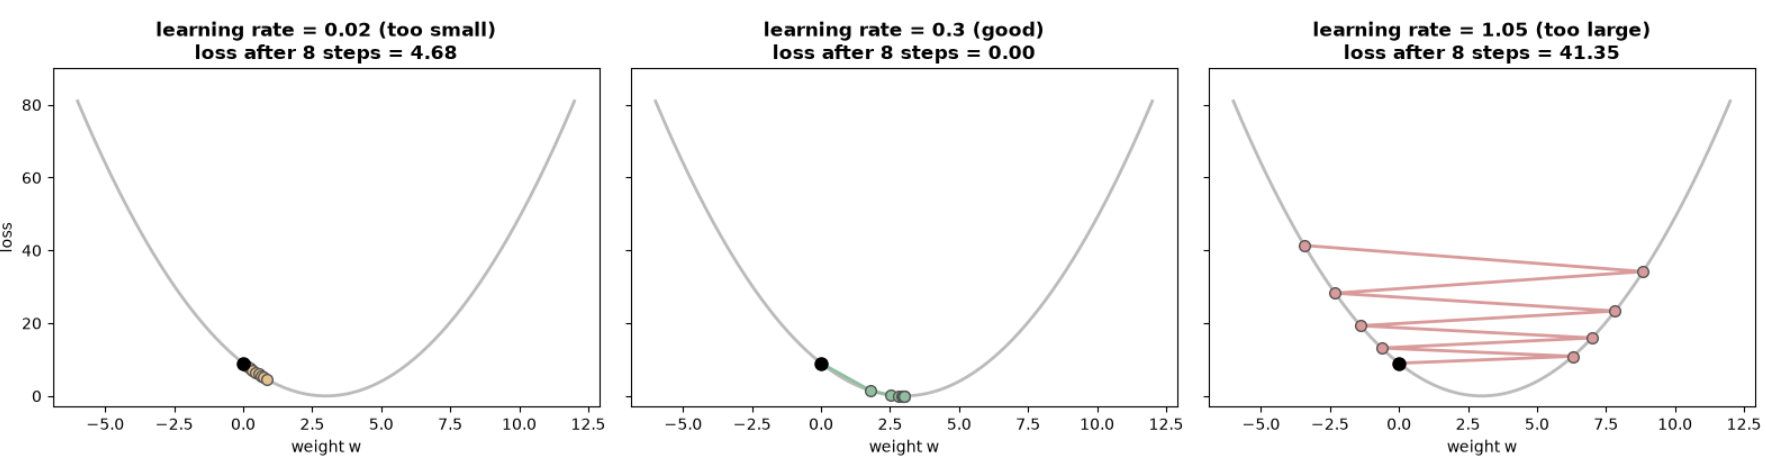

Same gradient, different step sizes, if we start at the black point. The goal is to reach the bottom

### 6. From one token to the training loss

Training doesn't look at just one token. The loss is calculated at **every position that has a label**, then **averaged** over all those positions and all examples in the batch. That average is the `loss` printed during training.

Not every token counts:
- **Padding tokens** get the label `-100`, and PyTorch's `CrossEntropyLoss` skips them (`ignore_index=-100`).
- With `completion_only_loss = True`, the **prompt tokens** also get `-100`, so only the answer counts.

So,

Every training step follows the same loop:
1. **Forward pass:** the model reads the input and outputs a probability for every token in its vocabulary.
2. **Loss:** cross-entropy compares those probabilities with the correct tokens.
3. **Backward pass:** gradients show how each trainable weight should change to make the loss smaller.
4. **Update:** the optimizer (for example Adam) nudges the weights. With LoRA, only the A and B matrices are updated.

Repeating this pushes the model to give **more probability to the correct tokens**, which makes the loss go down.

### 7. In our y/n fine-tuning

The completion is the label plus the EOS token, so the loss for one example is the average over just those two positions:

| Position | Correct token | Model's probability | Loss |
|---|---|---|---|
| Label | "y" | 0.70 | $-\ln 0.70 = 0.36$ |
| End | EOS | 0.95 | $-\ln 0.95 = 0.05$ |
| **Average** | | | **0.20** |

So training teaches the model two things at once: **which label to give** and **to stop right after it**.

### 8.  Reading the loss: perplexity

The loss is easier to interpret as **perplexity**:

$$\text{perplexity} = e^{\text{loss}}$$

Perplexity is roughly "how many equally likely options the model is choosing between."

| Loss | Perplexity | Meaning |
|---|---|---|
| 0.69 | 2.0 | Like a coin flip between 2 options (for us: guessing "y" or "n") |
| 0.11 | 1.1 | Almost always sure of the right answer |
| 0.01 | 1.01 | Essentially certain |

### Entropy vs. cross-entropy: don't mix them up

| | Entropy | Cross-entropy |
|---|---|---|
| Formula | $H(q) = -\sum_i q_i \ln q_i$ | $H(p, q) = -\sum_i p_i \ln q_i$ |
| Needs the correct answer? | **No** | **Yes** |
| Measures | How **uncertain** the prediction is | How **wrong** the prediction is |
| Used for | Inspecting the model's confidence | **Training** (it's the loss) |
| Our example | $-(0.7 \ln 0.7 + 0.2 \ln 0.2 + 0.1 \ln 0.1) = 0.80$ | $-\ln 0.7 = 0.36$ |

A model can have **low entropy and high cross-entropy** at the same time: very confident, but wrong. That's why we also evaluate with **accuracy, F1 or kappa**, not only with the loss.

### Summary

1. The LLM outputs a **logit** for every token. **Softmax** turns them into probabilities.
2. Cross-entropy (log loss) picks the probability of the **correct** token and takes **−ln** of it.
3. Low loss = high probability on the right answer. Confident mistakes are punished the most.
4. The gradient ($q - p$) raises the correct token's score and lowers the others.
5. The training loss is the **average** over all labelled tokens. Padding and prompt tokens (label −100) are skipped.
6. **Entropy** measures uncertainty and doesn't need the answer. **Cross-entropy** measures error and needs the answer.

> **Note:** PyTorch and Hugging Face use the natural log ($\ln$), so the loss is in "nats." Using $\log_2$ would give "bits," as in the entropy notebook. It's the same idea in a different unit.

In [27]:
import numpy as np

tokens = ["y", "n", "other"]
logits = np.array([2.0, 0.75, 0.06])
p = np.array([1, 0, 0])              # truth: the correct token is "y"
learning_rate = 1.0

for step in range(6):
    q = np.exp(logits) / np.exp(logits).sum()     # softmax
    loss = -np.log(q[0])                          # cross-entropy
    gradient = q - p                              # how the loss changes per logit
    print(f"step {step}: P(y) = {q[0]:.2f}  loss = {loss:.2f}  gradient = {gradient.round(2)}")
    logits = logits - learning_rate * gradient    # the optimizer step

step 0: P(y) = 0.70  loss = 0.36  gradient = [-0.3  0.2  0.1]
step 1: P(y) = 0.79  loss = 0.24  gradient = [-0.21  0.14  0.08]
step 2: P(y) = 0.84  loss = 0.18  gradient = [-0.16  0.1   0.06]
step 3: P(y) = 0.87  loss = 0.14  gradient = [-0.13  0.08  0.05]
step 4: P(y) = 0.89  loss = 0.12  gradient = [-0.11  0.07  0.04]
step 5: P(y) = 0.91  loss = 0.10  gradient = [-0.09  0.06  0.04]


### Info


* [Google ML Crash Course: Hyperparameters (learning rate, batch size, epochs)](https://developers.google.com/machine-learning/crash-course/linear-regression/hyperparameters): short and visual, with loss graphs for learning rates that are too small, too large and just right.
* [Cross Entropy](https://docs.pytorch.org/docs/2.6/generated/torch.nn.CrossEntropyLoss.html)